In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
import numpy as np
from tqdm import tqdm

In [ ]:
!pip install -U langchain-community langchain_groq huggingface_hub langchain-huggingface load_dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.9/469.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.79
    Uninstalling langchain-core-0.3.79:
      Successfully uninstalled langchain-core-0.3.79
  Attempting uninstall: langchain-text-splitters
    Found existing installation: langchain-text-splitters 0.3.11
    Uninstalling langchain-text-splitters-0.3.11:
      Successfu

In [ ]:
!pip install --upgrade langchain langchain-core langchain-text-splitters langchain langchain-openai openai faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.3/208.3 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.109.1
    Uninstalling openai-1.109.1:
      Successfully uninstalled openai-1.109.1
  Attempting uninstall: langchain
    Found existing installation: langchain 0.3.27
    Uninstalling langchain-0.3.27:
      Successfully uninstalled langchain-0.3.27


Index(['Task', 'LLAMA3.1', 'QWEN2.5', 'GPT4o-mini'], dtype='object')


<Figure size 1100x700 with 0 Axes>

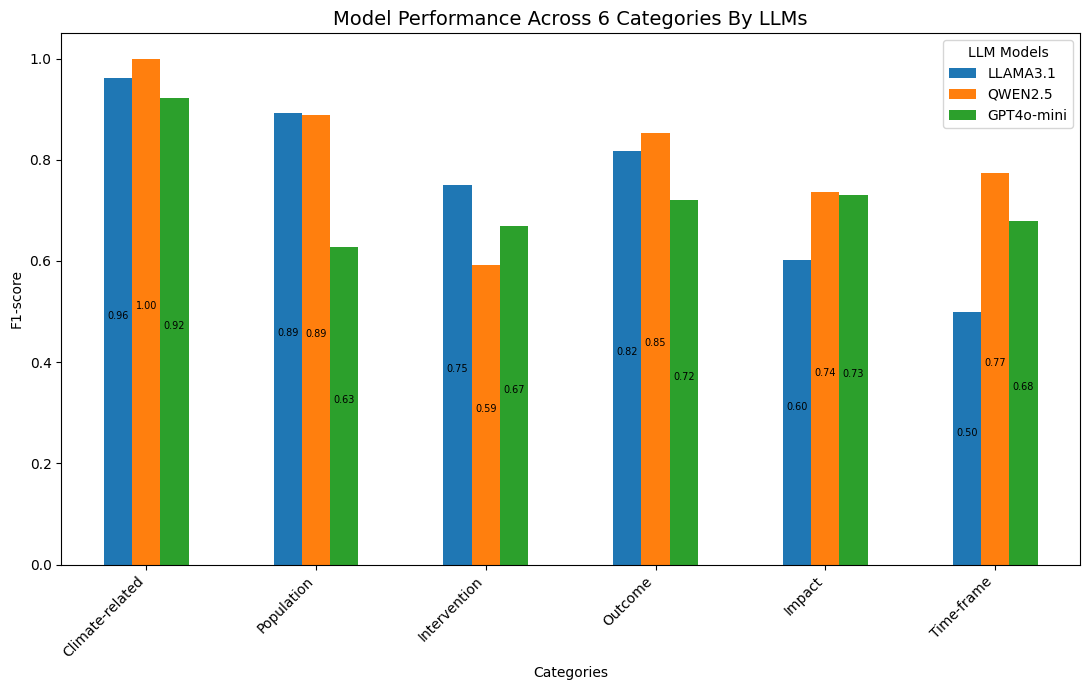

Index(['Task', 'LLAMA3.1', 'QWEN2.5', 'GPT4o-mini'], dtype='object')


<Figure size 1100x700 with 0 Axes>

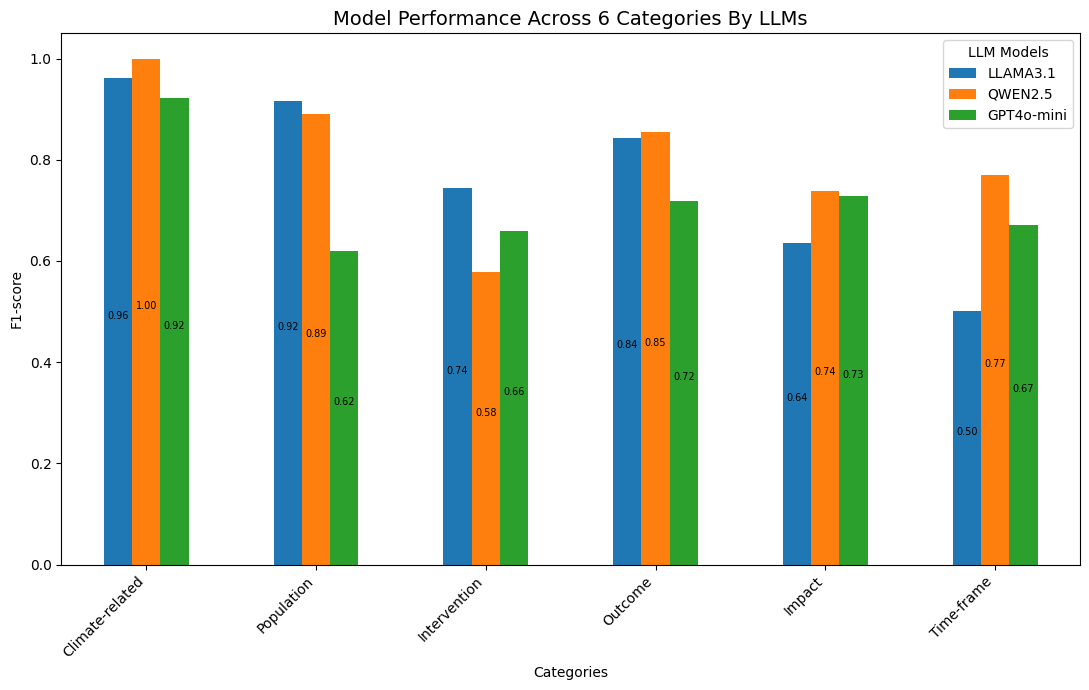

Index(['Task', 'LLAMA3.1', 'QWEN2.5', 'GPT4o-mini'], dtype='object')


<Figure size 1100x700 with 0 Axes>

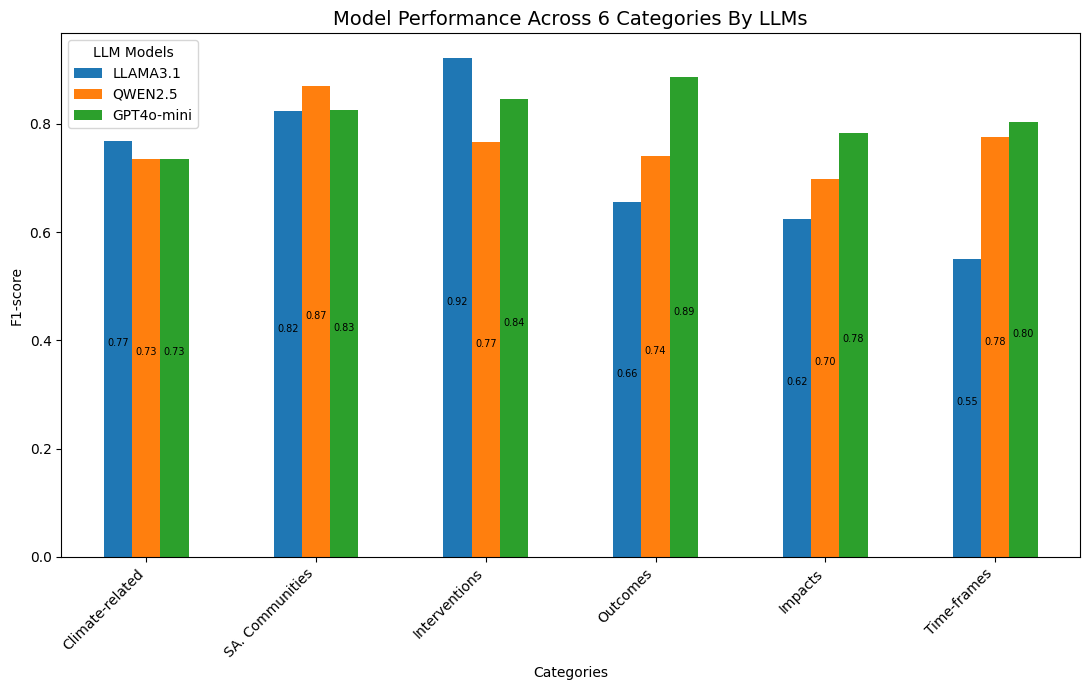

In [ ]:

# Load Excel file (update the path if needed)
df = pd.read_excel('researcher-maw - results.xlsx', sheet_name='Researcher-ngwenya')
df2 = pd.read_excel('researcher-maw - results.xlsx', sheet_name='Researcher-magwaza')
df3 = pd.read_excel('researcher-maw - results.xlsx', sheet_name='fixed_errors')

graphs = [{"data": df, "role": "Mandisa"}, {"data": df2, "role": "Mandlenkosi"}, {"data": df3, "role": "Summary"}]
for item in graphs:
    data = item["data"]
    role = item["role"]

    data.columns = data.columns.str.strip()
    print(data.columns)

    plt.figure(figsize=(11, 7))

    ax = data.plot(
        x='Task',
        kind='bar',
        figsize=(11, 7),
    )

    # df.plot(x='Task', kind='bar', figsize=(10, 6))
    plt.title(f'Model Performance Across 6 Categories By LLMs', fontsize=14)
    plt.ylabel('F1-score')
    plt.xlabel('Categories')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='LLM Models')

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", label_type="center",padding=4, fontsize=7)

    plt.tight_layout()
    plt.show()


# df2.columns = df2.columns.str.strip()
# print(df2.columns)

# plt.figure(figsize=(10, 6))
# # df2.plot(x='Task', kind='bar', figsize=(10, 6))
# plt.title('Model Performance Across Tasks - By Researcher 2', fontsize=14)
# plt.ylabel('F1-score')
# plt.xlabel('Task')
# plt.xticks(rotation=45, ha='right')
# plt.legend(title='Model')
# plt.tight_layout()
# plt.show()

In [ ]:
# print(df3.describe().to_json('text.json', orient='records'))
df3.describe()

,LLAMA3.1,QWEN2.5,GPT4o-mini
count,6.000000,6.000000,6.000000
mean,0.723833,0.764167,0.813167
std,0.137912,0.058105,0.052128
min,0.551000,0.698000,0.735000
25%,0.632000,0.736500,0.788250
50%,0.712000,0.754000,0.815000
75%,0.809250,0.773000,0.840250
max,0.921000,0.869000,0.886000


/tmp/ipython-input-2308030422.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  task_summary = merged.groupby("Task").apply(task_stats).reset_index()
/tmp/ipython-input-2308030422.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  model_summary = merged.groupby("Model").apply(task_stats).reset_index()


=== Task summary ===
              Task  mean_diff  mean_abs_diff  pearson_r  spearman_r
0  Climate-related   0.000000       0.000000   1.000000         1.0
1           Impact   0.011667       0.012333   0.998867         1.0
2     Intervention  -0.009333       0.009333   0.999991         1.0
3          Outcome   0.008333       0.010333   0.982665         1.0
4       Population   0.005667       0.011000   0.998027         1.0
5       Time-frame  -0.003333       0.004667   0.999678         1.0

=== Model summary ===
        Model  mean_diff  mean_abs_diff  pearson_r  spearman_r
0  GPT4o-mini  -0.004833       0.004833   0.999755         1.0
1    LLAMA3.1   0.013000       0.015000   0.995711         1.0
2     QWEN2.5  -0.001667       0.004000   0.999543         1.0

=== Overall ===
{'pearson_r': np.float64(0.9961119064624827), 'spearman_r': np.float64(0.9979360165118679), 'wilcoxon_stat': np.float64(56.5), 'wilcoxon_p': np.float64(0.8422411963158534), 'mean_diff': np.float64(0.002166666666

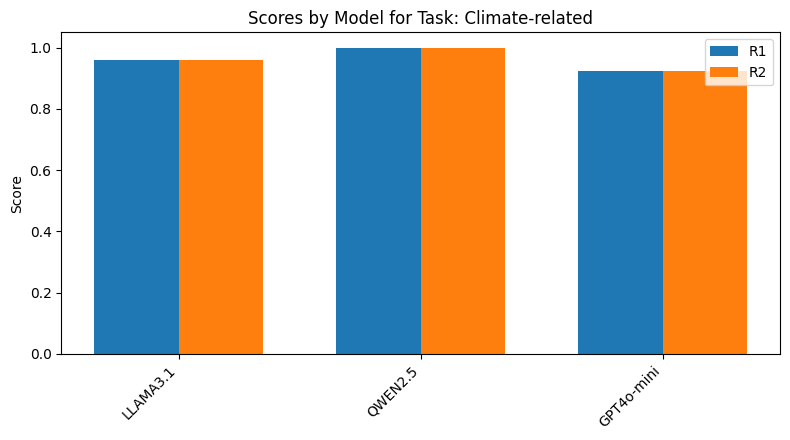

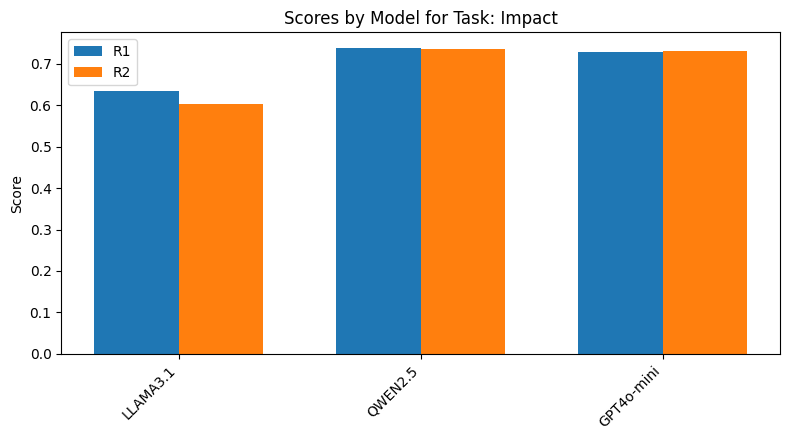

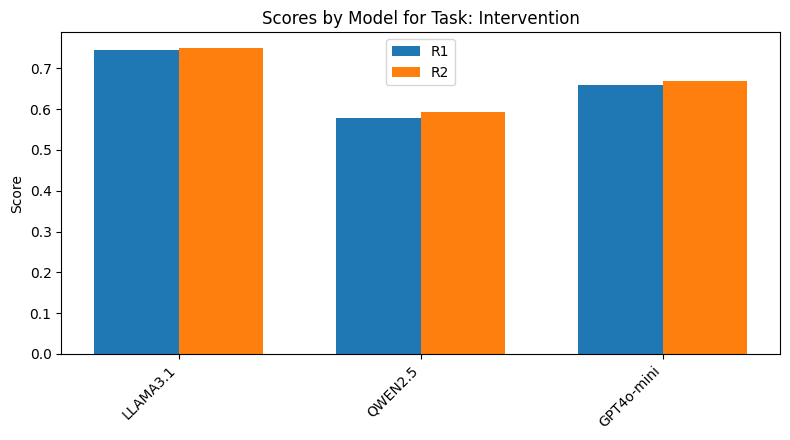

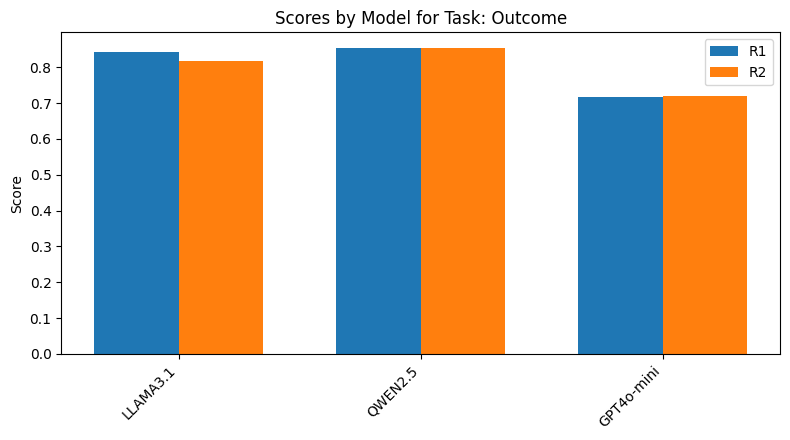

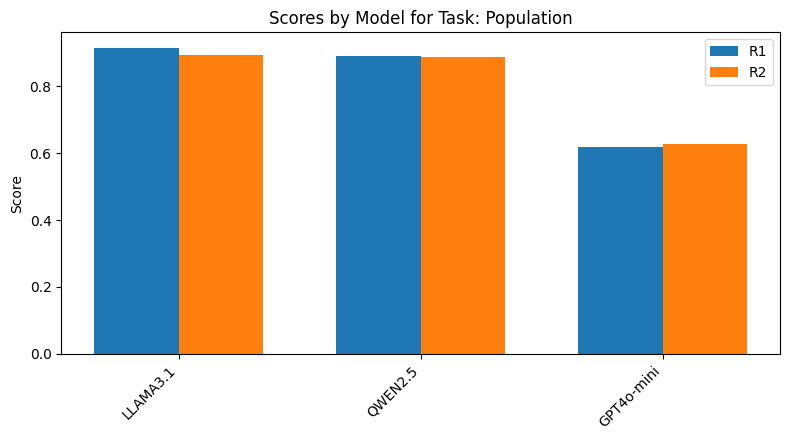

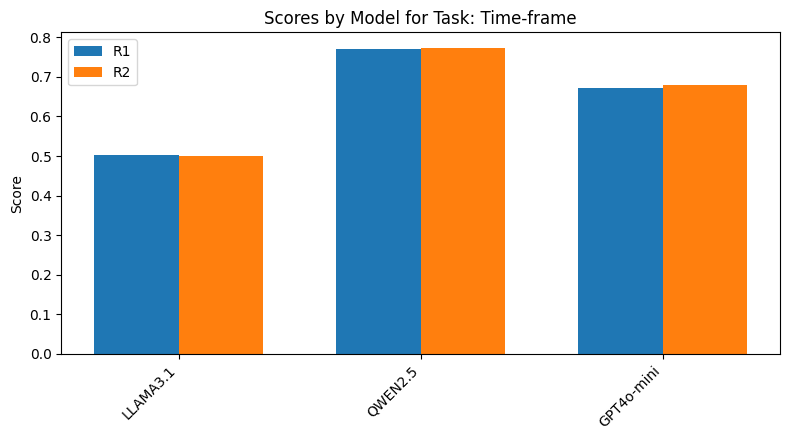

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, wilcoxon

# ------- 1. Load sheets -------
file = "researcher-maw - results.xlsx"   # update path if needed
r1 = pd.read_excel(file, sheet_name='Researcher-magwaza')
r2 = pd.read_excel(file, sheet_name='Researcher-ngwenya')

# Normalize column names and task column name
r1.columns = r1.columns.str.strip()
r2.columns = r2.columns.str.strip()
task_col = r1.columns[0]
r1 = r1.rename(columns={task_col: "Task"})
r2 = r2.rename(columns={task_col: "Task"})

# ------- 2. Melt (pivot) to long format -------
def melt_sheet(df, researcher_label):
    long = df.melt(id_vars="Task", var_name="Model", value_name="Score")
    long["Researcher"] = researcher_label
    # ensure numeric
    long["Score"] = pd.to_numeric(long["Score"], errors="coerce")
    return long

r1_long = melt_sheet(r1, "R1")
r2_long = melt_sheet(r2, "R2")

# ------- 3. Merge R1 and R2 by Task+Model to enable pairwise comparison -------
merged = pd.merge(
    r1_long.rename(columns={"Score":"Score_R1"})[["Task","Model","Score_R1"]],
    r2_long.rename(columns={"Score":"Score_R2"})[["Task","Model","Score_R2"]],
    on=["Task","Model"],
    how="inner"
)

# Add diffs
merged["diff"] = merged["Score_R1"] - merged["Score_R2"]
merged["abs_diff"] = merged["diff"].abs()

# ------- 4. Summary stats per Task -------
def task_stats(g):
    # drop NA pairs
    g = g.dropna(subset=["Score_R1","Score_R2"])
    if len(g) < 2:
        return pd.Series({"mean_diff": g["diff"].mean(), "mean_abs_diff": g["abs_diff"].mean(),
                          "pearson_r": np.nan, "spearman_r": np.nan})
    r_pearson, _ = pearsonr(g["Score_R1"], g["Score_R2"])
    r_spearman, _ = spearmanr(g["Score_R1"], g["Score_R2"])
    return pd.Series({"mean_diff": g["diff"].mean(), "mean_abs_diff": g["abs_diff"].mean(),
                      "pearson_r": r_pearson, "spearman_r": r_spearman})

task_summary = merged.groupby("Task").apply(task_stats).reset_index()

# ------- 5. Summary stats per Model -------
model_summary = merged.groupby("Model").apply(task_stats).reset_index()

# ------- 6. Overall statistics -------
overall_pearson, _ = pearsonr(merged["Score_R1"].dropna(), merged["Score_R2"].dropna())
overall_spearman, _ = spearmanr(merged["Score_R1"].dropna(), merged["Score_R2"].dropna())
wil_stat, wil_p = wilcoxon(merged["Score_R1"].dropna(), merged["Score_R2"].dropna())

overall = {
    "pearson_r": overall_pearson,
    "spearman_r": overall_spearman,
    "wilcoxon_stat": wil_stat,
    "wilcoxon_p": wil_p,
    "mean_diff": merged["diff"].mean(),
    "mean_abs_diff": merged["abs_diff"].mean()
}

# Print summaries
print("=== Task summary ===")
print(task_summary)
print("\n=== Model summary ===")
print(model_summary)
print("\n=== Overall ===")
print(overall)

# ------- 7. Charts -------

# A) For each Task: grouped bar chart (R1 vs R2 for each Model)
for task, g in merged.groupby("Task"):
    fig, ax = plt.subplots(figsize=(8,4.5))
    x = np.arange(len(g))
    width = 0.35
    ax.bar(x - width/2, g["Score_R1"], width, label="R1")
    ax.bar(x + width/2, g["Score_R2"], width, label="R2")
    ax.set_xticks(x)
    ax.set_xticklabels(g["Model"], rotation=45, ha='right')
    ax.set_ylabel("Score")
    ax.set_title(f"Scores by Model for Task: {task}")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef

# === 1️⃣ Load the file ===
file = "researcher-maw - results.xlsx"
r1 = pd.read_excel(file, sheet_name='Researcher-ngwenya')
r2 = pd.read_excel(file, sheet_name='Researcher-magwaza')

# === 2️⃣ Define tasks and models ===
tasks = ["climate_related", "impact_related", "community", "outcomes_related", "time_frame"]
models = ["GPT4o-mini", "QWEN2.5", "LLAMA3.1"]

records = []

# === 3️⃣ Compute metrics for each task and model ===
for task in tasks:
    for model in models:
        model_col = f"{task}_{model}"

        # skip if model column missing
        if model_col not in r1.columns:
            continue

        for researcher, researcher_name in [(r1, "Researcher 1"), (r2, "Researcher 2")]:
            if task not in researcher.columns:
                continue

            y_true = researcher[task].astype(int)
            y_pred = researcher[model_col].astype(int)

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall    = recall_score(y_true, y_pred, zero_division=0)
            f1        = f1_score(y_true, y_pred, zero_division=0)
            mcc       = matthews_corrcoef(y_true, y_pred)

            records.append({
                "Task": task.replace("_", " ").title(),
                "Researcher": researcher_name,
                "Model": model.replace("_", "-").upper(),
                "Precision": round(precision, 3),
                "Recall": round(recall, 3),
                "F1-score": round(f1, 3),
                "MCC": round(mcc, 3)
            })

# === 4️⃣ Combine into a single DataFrame ===
results_df = pd.DataFrame(records)
print("\n=== Performance Summary ===")
print(results_df)

# === 5️⃣ Save results (optional) ===
results_df.to_excel("climate_performance_researchers_models.xlsx", index=False)

# === 6️⃣ Visualization ===
melted = results_df.melt(
    id_vars=["Task", "Model", "Researcher"],
    value_vars=["Precision", "Recall", "F1-score", "MCC"],
    var_name="Metric", value_name="Score"
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=melted,
    x="Task", y="Score", hue="Metric", ci=None
)
plt.title("Model–Researcher Performance per Task", fontsize=14)
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

# === 7️⃣ (Optional) Average per Model ===
avg_model = results_df.groupby("Model")[["Precision","Recall","F1-score","MCC"]].mean().round(3)
print("\n=== Average Performance per Model ===")
print(avg_model)



=== Performance Summary ===
Empty DataFrame
Columns: []
Index: []


KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['Task', 'Model', 'Researcher', 'Precision', 'Recall', 'F1-score', 'MCC']"

In [ ]:
gpt_X_user_comparison_df = pd.read_excel('gpt_x_user_comparisons (1).xlsx')
llama_X_user_comparison_df = pd.read_excel('llama_x_user_comparisons.xlsx')
qwen_X_user_comparison_df = pd.read_excel('qwen_x_user_comparisons (1).xlsx')
gpt5_X_user_comparison_df = pd.read_excel('GOLD_gpt5_X_user_matches (1).xlsx')

In [ ]:
gpt_user_2_df = pd.read_excel('gpt_user_2_matches.xlsx')
llama_user_2_df = pd.read_excel('llama_user_2_matches.xlsx')
qwen_user_2_df = pd.read_excel('qwen_user_2_matches.xlsx')
gpt5_user_2_df = pd.read_excel('gpt5_user_2_matches.xlsx')


In [ ]:
gpt5_X_user_comparison_df = gpt5_X_user_comparison_df[~gpt5_X_user_comparison_df['text_user'].duplicated(keep='first')].sort_values(by="text_user", ascending=True).iloc[1:].reset_index(drop=True)
gpt_X_user_comparison_df = gpt_X_user_comparison_df[~gpt_X_user_comparison_df['text_user'].duplicated(keep='first')].sort_values(by="text_user", ascending=True).iloc[1:].reset_index(drop=True)
qwen_X_user_comparison_df = qwen_X_user_comparison_df[~qwen_X_user_comparison_df['text_user'].duplicated(keep='first')].sort_values(by="text_user", ascending=True).iloc[1:].reset_index(drop=True)
llama_X_user_comparison_df = llama_X_user_comparison_df[~llama_X_user_comparison_df['text_user'].duplicated(keep='first')].sort_values(by="text_user", ascending=True).iloc[1:].reset_index(drop=True)
print(len(gpt5_X_user_comparison_df))
print(len(gpt_X_user_comparison_df))
print(len(qwen_X_user_comparison_df))
print(len(llama_X_user_comparison_df))


26
26
26
26


In [ ]:
filter_text = list(gpt5_X_user_comparison_df['text_user'])
filter_text_x = list(gpt5_X_user_comparison_df['text_user'].str[:30])
print(filter_text_x)

['21-year-old South African sett', 'Abstract  A precondition for c', 'AbstractLevering change is har', 'According to the South African', 'Amidst the towering shadows of', 'Background. Climate change and', 'Background: The World Health O', 'In collaboration with the Cent', 'In urban settings, trees and g', 'Interested in studying at SAWC', 'Many people agree that one of ', 'Original article: https://doi.', 'Rapid urbanization is projecte', 'The Department of Forestry, Fi', 'The Greening Soweto tree-plant', 'The loss of natural habitat re', 'The vegetation of calcareous c', 'These eco-estates generally im', 'This document review evaluates', 'This paper aims to analyze the', 'This study addresses the phylo', 'This study assessed the preval', 'TreeKeepers Cape Town is a cit', 'Trees make communities and eco', 'What would you like to search ', '“Good habits formed at youth m']


In [ ]:
user_1_df = pd.read_excel('SDG 13 classification_maw_completed.xlsx')
user_2_df = pd.read_excel('user_2_matches_upd.xlsx')
print(len(user_1_df))
print(len(user_2_df))

37
35


In [ ]:
print(filter_text)

["21-year-old South African setting the bar high in luxury fashion_x000D_\nMen’s viral clothing brand Psycho Bunny has launched in South Africa_x000D_\nTyla makes stunning CFDA Awards debut in a sexy Gucci dress_x000D_\nFirst ever visually impaired doll, the blind Barbie is now here_x000D_\nThe Hussar Grill celebrates 60 years of premium family-friendly dining_x000D_\nSouth Africa’s recipe website (TASTE.co.za) ranked 5th globally_x000D_\nRestaurant review: the almost flawless ‘Ukko Experience’_x000D_\nTANG Sandton makes Top 100 Restaurants of the World 2023_x000D_\nFriends star blasts Elon Musk for ‘giving Kanye West a platform to spread hate’_x000D_\nSports that has been in trend in South Africa_x000D_\nChris Brown defies gravity – and abuse protest ban – sets Joburg stadium ablaze in epic “Breezy in South Africa” concert_x000D_\nAfricaCom 2024: Honor announces speaker lineup for Africa Tech Festival 2024 debut_x000D_\nTravel series: London was short, sharp and tweet_x000D_\nSpotligh

In [ ]:
researcher_maw_df = user_1_df[~user_1_df['text'].duplicated(keep='first')].sort_values(by="text", ascending=True).iloc[1:].reset_index(drop=True)
len(researcher_maw_df)

34

In [ ]:
researcher_mand_df = user_2_df[~user_2_df['text'].duplicated(keep='first')].sort_values(by="text", ascending=True).reset_index(drop=True)
len(researcher_mand_df)

35

In [ ]:
researcher_maw_filtered_df = researcher_maw_df[researcher_maw_df['text'].isin(filter_text)]

In [ ]:
list(researcher_mand_df['text'].str[:30])

['21-year-old South African sett',
 'Abstract A precondition for co',
 'Abstract Change detecting land',
 'AbstractLevering change is har',
 'According to the South African',
 'Amidst the towering shadows of',
 'Background. Climate change and',
 'Background: The World Health O',
 'Becoming a monthly WESSA donor',
 'During the first weekend of Ap',
 'Here at Timberland South Afric',
 'In collaboration with the Cent',
 'In urban settings, trees and g',
 'Interested in studying at SAWC',
 'Many people agree that one of ',
 'Original article: Errors that ',
 'Platbos Forest Planting trees ',
 'Please let us know if there ar',
 'Rapid urbanization is projecte',
 'Siyabulela Sokomani, Founder a',
 'Southern Sun and Miss Earth So',
 'The Department of Forestry, Fi',
 'The Department of Forestry, Fi',
 'The Greening Soweto tree-plant',
 'The loss of natural habitat re',
 'The vegetation of calcareous c',
 'These eco-estates generally im',
 'This document review evaluates',
 'This paper aims to

In [ ]:
researcher_mand_filtered_df = researcher_mand_df[researcher_mand_df['text'].isin(filter_text)]
researcher_mand_filtered_df.head(20)

,Unnamed: 0,Respondent_ID,Timestamp,text,climate_related,impact_related,outcomes_related,project_date,sdg_intervention,community,user_2_community,user_2_climate_related,user_2_impact_related,user_2_project_date,user_2_sdg_intervention,user_2_outcomes_related
3,3,1,2025/10/04 12:34:39 am EEST,"AbstractLevering change is hard, and an increm...",NO,NO,NO,NO,NO,NO,True,False,True,True,False,True
4,32,1,2025/10/04 12:34:39 am EEST,According to the South African National Biodiv...,YES,YES,YES,YES,YES,YES,True,True,True,True,True,True
7,4,1,2025/10/04 12:34:39 am EEST,Background: The World Health Organization (WHO...,NO,NO,NO,NO,NO,YES,True,False,True,True,False,True
12,7,1,2025/10/04 12:34:39 am EEST,"In urban settings, trees and greenery play a v...",YES,YES,YES,NO,YES,YES,True,True,True,True,True,True
18,9,1,2025/10/04 12:34:39 am EEST,Rapid urbanization is projected for African ci...,YES,YES,YES,NO,YES,YES,True,True,True,True,True,True
23,30,1,2025/10/04 12:34:39 am EEST,The Greening Soweto tree-planting project was ...,YES,YES,YES,YES,YES,YES,True,True,True,True,True,True
25,14,1,2025/10/04 12:34:39 am EEST,The vegetation of calcareous coastal dunes of ...,YES,YES,YES,NO,YES,YES,True,True,True,True,True,True
26,29,1,2025/10/04 12:34:39 am EEST,These eco-estates generally improve species an...,YES,YES,YES,NO,YES,YES,True,True,True,True,True,True
27,10,1,2025/10/04 12:34:39 am EEST,This document review evaluates modes of approp...,YES,YES,YES,NO,YES,YES,True,True,True,True,True,True
28,13,1,2025/10/04 12:34:39 am EEST,This paper aims to analyze the effects of biod...,YES,YES,YES,NO,YES,YES,True,True,True,True,True,True


In [ ]:
researcher_mand_filtered_df = researcher_mand_df[
    researcher_mand_df['text'].str[:20].isin([t[:20] for t in filter_text])
]
len(researcher_mand_filtered_df)

25

In [ ]:
mandisa_df = researcher_mand_filtered_df[['user_2_community',
       'user_2_climate_related', 'user_2_impact_related',
       'user_2_project_date', 'user_2_sdg_intervention',
       'user_2_outcomes_related']]

In [ ]:
# for x in range(len(researcher_mand_filtered_df)):
#   full_text = researcher_mand_filtered_df.iloc[x]['text']
#   print(full_text)
#   print(str("\n**********" * 5))

In [ ]:
mand_df = maw_filtered_df[['user__community',
       'user__climate_related', 'user__impact_related',
       'user__project_date', 'user__sdg_intervention',
       'user__outcomes_related']]

NameError: name 'maw_filtered_df' is not defined

In [ ]:
all_text = researcher_mand_filtered_df['text'].tolist()


In [ ]:
maw_filtered_df = gpt_X_user_comparison_df[
    gpt_X_user_comparison_df['text_user'].str[:20].isin([t[:20] for t in filter_text])
]
len(maw_filtered_df)

26

In [ ]:
gpt5_X_user_comparison_df.columns

Index(['Unnamed: 0', 'summary_gold', 'community_gold', 'project_name_gold',
       'time_frame_gold', 'future_goals_gold', 'intervention_gold',
       'outcome_gold', 'impact_gold', 'sdg_13_3_gold', 'sa_project_gold',
       'climate_related', 'text_gold', 'index_gold', 'url_gold',
       'project_name:',
       'project_name: "Holocene Dune Vegetation Quantitative Analysis"',
       'project_name: ', 'gpt_community', 'gpt_climate_related',
       'gpt_impact_related', 'gpt_project_date', 'gpt_sdg_intervention',
       'gpt_outcomes_related', 'prefix', 'annotation_id', 'annotator',
       'user__climate_related', 'community_user', 'user__community',
       'created_at', 'future_goals_user', 'id', 'impact_user',
       'user__impact_related', 'index_user', 'intervention_user', 'lead_time',
       'user__outcomes_related', 'outcome_user', 'user__project_date',
       'project_name_user', 'sa_project_user', 'sdg_13_3_user',
       'user__sdg_intervention', 'summary_user', 'text_user',
   

In [ ]:
researcher_mand_filtered_df[['text','user_2_community',
       'user_2_climate_related', 'user_2_impact_related',
       'user_2_project_date', 'user_2_sdg_intervention',
       'user_2_outcomes_related']].to_excel('researcher_mand_filtered_df_TESTING.xlsx')

In [ ]:
gpt5_X_user_comparison_df[['text_gold','climate_related','sdg_13_3_gold'
# , 'community_gold', 'project_name_gold',
#        'time_frame_gold', 'future_goals_gold', 'intervention_gold',
#        'outcome_gold', 'impact_gold'
       ]]

,text_gold,climate_related,sdg_13_3_gold
0,21-year-old South African setting the bar high...,YES,YES — the initiative includes environmental ed...
1,Abstract A precondition for colour vision is ...,NO,NO - The study concerns insect visual physiolo...
2,"AbstractLevering change is hard, and an increm...",NO,NO - The work focuses on mathematics education...
3,According to the South African National Biodiv...,YES,YES — The focus on wetlands as an adaptation m...
4,"Amidst the towering shadows of climate change,...",YES,"YES - The interventions emphasize education, a..."
5,Background. Climate change and polluting healt...,YES,YES — The study assesses and seeks to improve ...
6,Background: The World Health Organization (WHO...,NO,NO - The study focuses on medicinal plant–anti...
7,In collaboration with the Centre for Human Rig...,YES,"YES (The conference focuses on education, awar..."
8,"In urban settings, trees and greenery play a v...",YES,YES — The study provides evidence and analysis...
9,Interested in studying at SAWC? Our mission as...,YES,"YES — The College’s education, training and ca..."


In [ ]:
# new_df = gpt5_X_user_comparison_df[['user__climate_related', 'user__community',
#        'user__impact_related', 'user__outcomes_related', 'user__sdg_intervention', 'user__project_date']]
# gpt5_X_user_comparison_df.columns
base_df = gpt5_X_user_comparison_df[["Unnamed: 0",'text_user','user__climate_related', 'user__community',
       'user__impact_related', 'user__outcomes_related', 'user__sdg_intervention', 'user__project_date']]
base_filtered_df = base_df[
    base_df['text_user'].str[:20].isin([t[:20] for t in filter_text])
]
len(base_filtered_df)

26

In [ ]:
base_filtered_df.iloc[:]

NameError: name 'base_filtered_df' is not defined

In [ ]:
len(gpt5_X_user_comparison_df)

26

In [ ]:
# Example DataFrame: r1
import pandas as pd

true_false_counts = mandisa_df.apply(lambda x: x.value_counts()).fillna(0).astype(int)
print(true_false_counts)


       user_2_community  user_2_climate_related  user_2_impact_related  \
False                 0                       3                      0   
True                 25                      22                     25   

       user_2_project_date  user_2_sdg_intervention  user_2_outcomes_related  
False                    0                        3                        0  
True                    25                       22                       25  


In [ ]:
# Example DataFrame: r1
import pandas as pd

true_false_counts = new_df.apply(lambda x: x.value_counts()).fillna(0).astype(int)
print(true_false_counts)


       user__climate_related  user__community  user__impact_related  \
True                      13               21                    15   
False                     13                5                    11   

       user__outcomes_related  user__sdg_intervention  user__project_date  
True                       18                      20                  13  
False                       8                       6                  13  


In [ ]:
researcher_mand_filtered_df.columns

Index(['Unnamed: 0', 'Respondent_ID', 'Timestamp', 'text', 'climate_related',
       'impact_related', 'outcomes_related', 'project_date',
       'sdg_intervention', 'community', 'user_2_community',
       'user_2_climate_related', 'user_2_impact_related',
       'user_2_project_date', 'user_2_sdg_intervention',
       'user_2_outcomes_related'],
      dtype='object')

In [ ]:
# researcher_mand_filtered_df[['Unnamed: 0','user_2_climate_related', 'text']]
researcher_mand_filtered_df[researcher_mand_df['Unnamed: 0'].isin([3, 4, 8])]

/tmp/ipython-input-168467669.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  researcher_mand_filtered_df[researcher_mand_df['Unnamed: 0'].isin([3, 4, 8])]


,Unnamed: 0,Respondent_ID,Timestamp,text,climate_related,impact_related,outcomes_related,project_date,sdg_intervention,community,user_2_community,user_2_climate_related,user_2_impact_related,user_2_project_date,user_2_sdg_intervention,user_2_outcomes_related
3,3,1,2025/10/04 12:34:39 am EEST,"AbstractLevering change is hard, and an increm...",NO,NO,NO,NO,NO,NO,True,False,True,True,False,True
7,4,1,2025/10/04 12:34:39 am EEST,Background: The World Health Organization (WHO...,NO,NO,NO,NO,NO,YES,True,False,True,True,False,True
29,8,1,2025/10/04 12:34:39 am EEST,This study addresses the phylogenetic relation...,NO,NO,NO,NO,NO,YES,True,False,True,True,False,True


In [ ]:
researcher_mand_filtered_df['Timestamp']

,Timestamp
0,2025/10/04 12:34:39 am EEST
3,2025/10/04 12:34:39 am EEST
4,2025/10/04 12:34:39 am EEST
5,2025/10/04 12:34:39 am EEST
6,2025/10/04 12:34:39 am EEST
7,2025/10/04 12:34:39 am EEST
11,2025/10/04 12:34:39 am EEST
12,2025/10/04 12:34:39 am EEST
13,2025/10/04 12:34:39 am EEST
14,2025/10/04 12:34:39 am EEST


In [ ]:
df_wide.head()

,Respondent_ID,Timestamp,URL,Index,Question_Text,Climate-Related,Has Cliamate-Related Impact,Has Climate-Related Outcome,Mentions Project Timeframe,Mentions SDG 13 Interventions,South African Communities
0,1,2025/10/04 12:34:39 am EEST,https://afr100.org/project/regreening-south-af...,0,"Siyabulela Sokomani, Founder and Managing Dire...",YES,YES,YES,YES,YES,YES
1,1,2025/10/04 12:34:39 am EEST,https://afr100.org/project/regreening-south-af...,17,Original article: Errors that appear in the Di...,YES,YES,YES,YES,YES,YES
2,1,2025/10/04 12:34:39 am EEST,https://afripoli.org/rising-voices-the-african...,0,"Amidst the towering shadows of climate change,...",YES,YES,YES,NO,YES,NO
3,1,2025/10/04 12:34:39 am EEST,https://doi.org/10.1007/s43621-025-01111-1,72,"AbstractLevering change is hard, and an increm...",NO,NO,NO,NO,NO,NO
4,1,2025/10/04 12:34:39 am EEST,https://doi.org/10.1016/j.regsus.2025.100194,294,Background: The World Health Organization (WHO...,NO,NO,NO,NO,NO,YES


In [ ]:
researcher_maw_filtered_df[['lead_time']]

,lead_time
0,294.495
1,42.166
2,90.813
4,225.480
5,741.725
6,399.191
7,102.032
8,13497.296
9,89.137
10,147.064


In [ ]:
2*60/3600

0.016666666666666666

In [ ]:
lead_times = researcher_maw_filtered_df["lead_time"]

print("Average time per annotation:", lead_times.mean(), "seconds")
print("Total time spent (minutes):", lead_times.sum() / 60)
print("Total time spent (hours):", lead_times.sum() / (60*60))

Average time per annotation: 818.9567307692307 seconds
Total time spent (minutes): 354.88125
Total time spent (hours): 5.9146875


In [ ]:
gpt_X_user1 = gpt_X_user_comparison_df[['gpt_community', 'gpt_climate_related', 'gpt_impact_related', 'gpt_project_date', 'gpt_sdg_intervention', 'gpt_outcomes_related']]
llama_X_user1 = llama_X_user_comparison_df[['qwen_community', 'gpt_climate_related', 'gpt_impact_related', 'gpt_project_date', 'gpt_sdg_intervention', 'gpt_outcomes_related']]
qwen_X_user1 = qwen_X_user_comparison_df[['qwen_community', 'gpt_climate_related', 'gpt_impact_related', 'gpt_project_date', 'gpt_sdg_intervention', 'gpt_outcomes_related']]


In [ ]:
qwen_X_user1.columns

Index(['qwen_community', 'gpt_climate_related', 'gpt_impact_related',
       'gpt_project_date', 'gpt_sdg_intervention', 'gpt_outcomes_related'],
      dtype='object')

In [ ]:
gpt_X_user2 = gpt_user_2_df[['gpt_community', 'gpt_climate_related', 'gpt_impact_related', 'gpt_project_date', 'gpt_sdg_intervention', 'gpt_outcomes_related']]
llama_X_user2 = llama_user_2_df[['llama_community', 'llama_climate_related', 'llama_impact_related', 'llama_project_date', 'llama_sdg_intervention', 'llama_outcomes_related']]
qwen_X_user2 = qwen_user_2_df[['qwen_community', 'gpt_climate_related', 'gpt_impact_related', 'gpt_project_date', 'gpt_sdg_intervention', 'gpt_outcomes_related']]

In [ ]:
llama_X_user1 = llama_X_user1.rename(columns={'qwen_community': 'gpt_community'})
qwen_X_user2 = qwen_X_user2.rename(columns={'qwen_community': 'gpt_community'})
qwen_X_user1 = qwen_X_user1.rename(columns={'qwen_community': 'gpt_community'})


In [ ]:
print(len(gpt_X_user1))
print(len(gpt_X_user2))
print(len(qwen_X_user1))
print(len(qwen_X_user2))
print(len(llama_X_user1))
print(len(llama_X_user2))

26
26
26
26
26
26


In [ ]:
llama_X_user2 = llama_X_user2.rename(columns={'llama_community': 'gpt_community', 'llama_climate_related': 'gpt_climate_related', 'llama_impact_related': 'gpt_impact_related',
       'llama_project_date': 'gpt_project_date', 'llama_sdg_intervention': 'gpt_sdg_intervention',
       'llama_outcomes_related': 'gpt_outcomes_related'})

In [ ]:
user1_cols = [c for c in llama_X_user_comparison_df.columns if c.startswith("user_")]
user2_cols = [c for c in llama_user_2_df.columns if c.startswith("user_2")]
print('USER-1 COLUMNS', user1_cols)
print('USER-2 COLUMNS', user2_cols)

USER-1 COLUMNS ['user__climate_related', 'user__community', 'user__impact_related', 'user__outcomes_related', 'user__project_date', 'user__sdg_intervention']
USER-2 COLUMNS ['user_2_community', 'user_2_climate_related', 'user_2_impact_related', 'user_2_project_date', 'user_2_sdg_intervention', 'user_2_outcomes_related']


In [ ]:
from sklearn.metrics import classification_report, f1_score, cohen_kappa_score

In [ ]:
results = {}
user_climate = (llama_X_user_comparison_df['user__climate_related']).astype(bool)
gold_climate = (llama_user_2_df['user_2_climate_related']).astype(bool)
y_true = user_climate # target_df[gpt_col].astype(str)  # ground truth
y_pred = gold_climate #target_df[user_col].astype(str)  # predictions

f1 = f1_score(y_true, y_pred, average="weighted")
report = classification_report(y_true, y_pred, output_dict=True)

results["climate_change"] = {
    "f1_score": f1,
    "report": report
}

kappa = cohen_kappa_score(y_true, y_pred)
print("Cohen's Kappa:", kappa)

print("my results", results)


Cohen's Kappa: 0.07692307692307687
my results {'climate_change': {'f1_score': 0.4583333333333333, 'report': {'False': {'precision': 0.6666666666666666, 'recall': 0.15384615384615385, 'f1-score': 0.25, 'support': 13.0}, 'True': {'precision': 0.5217391304347826, 'recall': 0.9230769230769231, 'f1-score': 0.6666666666666666, 'support': 13.0}, 'accuracy': 0.5384615384615384, 'macro avg': {'precision': 0.5942028985507246, 'recall': 0.5384615384615385, 'f1-score': 0.4583333333333333, 'support': 26.0}, 'weighted avg': {'precision': 0.5942028985507246, 'recall': 0.5384615384615384, 'f1-score': 0.4583333333333333, 'support': 26.0}}}}


In [ ]:
# print(user_climate)
# print(gold_climate)

In [ ]:
def get_field_pairs(predict_cols, user_cols, comparator="gpt_"):
  pairs = []
  for u_col in user_cols:
      prefix = u_col[6:]  # remove "_user"
      # prefix = u_col[7:]  # remove "_user"
      print('prefix', prefix, u_col)
      g_col =  comparator + prefix
      print('g col', g_col)

      if g_col in predict_cols:
          pairs.append((u_col, g_col))
  # print(pairs)
  return pairs

In [ ]:
models = {
    "GPT": (gpt_X_user1, gpt_X_user2),
    "Qwen": (qwen_X_user1, qwen_X_user2),
    "Llama": (llama_X_user1, llama_X_user2)
}


In [ ]:
from sklearn.metrics import cohen_kappa_score
import pandas as pd

kappa_results = []

for model_name, (r1_df, r2_df) in models.items():
    for col in r1_df.columns:
        y1 = r1_df[col].astype(str)
        y2 = r2_df[col].astype(str)
        kappa = cohen_kappa_score(y1, y2)
        kappa_results.append({
            "Model": model_name,
            "Task": col,
            "Kappa": kappa
        })

kappa_df = pd.DataFrame(kappa_results)
print(kappa_df)


    Model                  Task     Kappa
0     GPT         gpt_community -0.215827
1     GPT   gpt_climate_related  0.153846
2     GPT    gpt_impact_related -0.153846
3     GPT      gpt_project_date -0.125984
4     GPT  gpt_sdg_intervention  0.000000
5     GPT  gpt_outcomes_related -0.036810
6    Qwen         gpt_community  0.177215
7    Qwen   gpt_climate_related  0.153846
8    Qwen    gpt_impact_related  0.040268
9    Qwen      gpt_project_date -0.076433
10   Qwen  gpt_sdg_intervention -0.355828
11   Qwen  gpt_outcomes_related  0.424779
12  Llama         gpt_community       NaN
13  Llama   gpt_climate_related  0.299401
14  Llama    gpt_impact_related -0.181818
15  Llama      gpt_project_date -0.323353
16  Llama  gpt_sdg_intervention  0.299401
17  Llama  gpt_outcomes_related       NaN


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


In [ ]:
from sklearn.metrics import classification_report, matthews_corrcoef, balanced_accuracy_score

y_true = [1,1,1,1,1,1,1,1,0,0,0]   # imbalanced (mostly positive)
y_pred = [1,1,1,1,0,1,1,0,0,0,0]

print(classification_report(y_true, y_pred, digits=3))
print("MCC:", round(matthews_corrcoef(y_true, y_pred), 3))
print("Balanced Accuracy:", round(balanced_accuracy_score(y_true, y_pred), 3))


              precision    recall  f1-score   support

           0      0.600     1.000     0.750         3
           1      1.000     0.750     0.857         8

    accuracy                          0.818        11
   macro avg      0.800     0.875     0.804        11
weighted avg      0.891     0.818     0.828        11

MCC: 0.671
Balanced Accuracy: 0.875


**Question**

In [ ]:
from google.colab import userdata
import ast
import json
import re

In [ ]:
OPENAI_KEY = userdata.get('openai')
GROQ_KEY = userdata.get('groq')
HF_KEY = userdata.get('HF_TOKEN')

### Climate Literacy Impact: Anchor statements
clii_anchors = {
    "Cognitive": [
        "knowledge about climate change, e.g. Knowing that the melting of permafrost affects the Earth's climate or understanding the role of roof gardens in reducing carbon dioxide levels, notes UNCC:Learn",
        "understanding of environmental issues e.g. Recognizing that burning fossil fuels for power, cutting down forests, and manufacturing goods are major causes of climate change and that these actions lead to effects like rising temperatures and extreme weather events, according to the United Nations and the National Oceanic and Atmospheric Administration (NOAA).",
        "climate literacy and awareness, e.g. analyzing news articles or social media posts about climate change, discerning scientific consensus from misinformation, and understanding the uncertainties in scientific findings"
    ],
    "Affective": [
        "emotional response to climate change, e.g. This category includes a range of emotions such as eco-anxiety, a chronic fear of environmental doom; guilt about personal lifestyle choices; sadness and grief over the loss of ecosystems; and anger at inaction from governments and corporations. These negative emotions can be contrasted with hope and optimism, which can also motivate positive action.",
        "motivation to take action, e.g. The motivation to act on climate change is driven by a sense of duty and responsibility to future generations. It also relies on a person's efficacy beliefs, or the conviction that their actions can make a difference. Health and safety concerns, when climate change is framed as a direct threat to personal well-being, are also powerful motivators.",
        "concern and care for the environment, e.g. A person's level of concern is strongly linked to their emotional connection to nature and a deep sense of belonging to the natural world. Conversely, psychological distancing—the feeling that climate change is a problem for someone else—can reduce a person's concern. Finally, social norms and influence play a role, as people are often motivated to adopt pro-environmental behaviors to align with their social group. "
    ],
    "Behavioral": [
        "Actions to mitigate climate change: These encompass both individual and large-scale actions aimed at reducing or preventing greenhouse gas emissions. Examples include reducing personal energy consumption, adopting renewable energy sources, and switching to sustainable transport like walking, biking, or electric vehicles. It also involves lifestyle changes such as eating more plant-based foods, reducing food waste, and consciously minimizing consumption of goods like fast fashion and plastics.",
        "Community participation in sustainability: This involves the active and genuine involvement of people in addressing local problems and implementing projects to promote sustainable development. Participation can be driven by a motivation to improve one's community, building a sense of collective purpose. Strategies include community needs assessments, mobilization, and working with local authorities. It is crucial that participation is inclusive, involving women and other vulnerable groups, and that agencies or governments respect local knowledge and needs.",
        "Adoption of eco-friendly practices: The adoption of eco-friendly practices by individuals and organizations includes a range of actions that minimize environmental harm, reduce waste, and conserve energy. Examples involve using reusable items, recycling, upcycling, composting, and conserving water. In the corporate sector, this includes implementing strategies to reduce a company's carbon footprint, investing in sustainable supply chains, and offering eco-friendly products."
        ],
    "Institutional": [
        "policy development for climate adaptation: Effective policy-making for climate change adaptation involves national and sub-national governments developing strategies and measures to reduce vulnerability to climate impacts. This includes implementing large-scale measures like enhancing early warning systems, strengthening infrastructure, and developing strategies for managing water, land, and food systems. It also requires a 'whole-of-government' approach and integrating climate considerations into development plans.",
        "Governance and institutional support: This involves building robust institutional arrangements and governance models to address social problems like climate change and ensure sustainable development. Good governance is characterized by participatory behaviour, transparency, accountability, and coordination across different levels of government. Institutional support, often technical and strategic, is aimed at strengthening government departments to improve financial management, service delivery, and overall effectiveness.",
        "Capacity building in organizations: This is the process of helping individuals, organizations, and communities strengthen their skills, knowledge, and systems to achieve their goals. For organizations, this involves upskilling and reskilling employees, developing leadership, forming partnerships, and upgrading technology and processes. Ultimately, capacity building aims to transform behaviours and improve an organization's ability to achieve its mission."
    ]
}


In [ ]:
clii_anchors = {
    "Cognitive": [
        "knowledge about climate change, e.g. Knowing that the melting of permafrost affects the Earth's climate or understanding the role of roof gardens in reducing carbon dioxide levels, notes UNCC:Learn",
        "understanding of environmental issues e.g. Recognizing that burning fossil fuels for power, cutting down forests, and manufacturing goods are major causes of climate change and that these actions lead to effects like rising temperatures and extreme weather events, according to the United Nations and the National Oceanic and Atmospheric Administration (NOAA).",
        "climate literacy and awareness, e.g. analyzing news articles or social media posts about climate change, discerning scientific consensus from misinformation, and understanding the uncertainties in scientific findings"
    ],
    "Affective": [
        "emotional response to climate change, e.g. This category includes a range of emotions such as eco-anxiety, a chronic fear of environmental doom; guilt about personal lifestyle choices; sadness and grief over the loss of ecosystems; and anger at inaction from governments and corporations. These negative emotions can be contrasted with hope and optimism, which can also motivate positive action.",
        "motivation to take action, e.g. The motivation to act on climate change is driven by a sense of duty and responsibility to future generations. It also relies on a person's efficacy beliefs, or the conviction that their actions can make a difference. Health and safety concerns, when climate change is framed as a direct threat to personal well-being, are also powerful motivators.",
        "concern and care for the environment, e.g. A person's level of concern is strongly linked to their emotional connection to nature and a deep sense of belonging to the natural world. Conversely, psychological distancing—the feeling that climate change is a problem for someone else—can reduce a person's concern. Finally, social norms and influence play a role, as people are often motivated to adopt pro-environmental behaviors to align with their social group. "
    ],
    "Behavioral": [
        "Actions to mitigate climate change: These encompass both individual and large-scale actions aimed at reducing or preventing greenhouse gas emissions. Examples include reducing personal energy consumption, adopting renewable energy sources, and switching to sustainable transport like walking, biking, or electric vehicles. It also involves lifestyle changes such as eating more plant-based foods, reducing food waste, and consciously minimizing consumption of goods like fast fashion and plastics.",
        "Community participation in sustainability: This involves the active and genuine involvement of people in addressing local problems and implementing projects to promote sustainable development. Participation can be driven by a motivation to improve one's community, building a sense of collective purpose. Strategies include community needs assessments, mobilization, and working with local authorities. It is crucial that participation is inclusive, involving women and other vulnerable groups, and that agencies or governments respect local knowledge and needs.",
        "Adoption of eco-friendly practices: The adoption of eco-friendly practices by individuals and organizations includes a range of actions that minimize environmental harm, reduce waste, and conserve energy. Examples involve using reusable items, recycling, upcycling, composting, and conserving water. In the corporate sector, this includes implementing strategies to reduce a company's carbon footprint, investing in sustainable supply chains, and offering eco-friendly products."
        ],
    "Institutional": [
        "policy development for climate adaptation: Effective policy-making for climate change adaptation involves national and sub-national governments developing strategies and measures to reduce vulnerability to climate impacts. This includes implementing large-scale measures like enhancing early warning systems, strengthening infrastructure, and developing strategies for managing water, land, and food systems. It also requires a 'whole-of-government' approach and integrating climate considerations into development plans.",
        "Governance and institutional support: This involves building robust institutional arrangements and governance models to address social problems like climate change and ensure sustainable development. Good governance is characterized by participatory behaviour, transparency, accountability, and coordination across different levels of government. Institutional support, often technical and strategic, is aimed at strengthening government departments to improve financial management, service delivery, and overall effectiveness.",
        "Capacity building in organizations: This is the process of helping individuals, organizations, and communities strengthen their skills, knowledge, and systems to achieve their goals. For organizations, this involves upskilling and reskilling employees, developing leadership, forming partnerships, and upgrading technology and processes. Ultimately, capacity building aims to transform behaviours and improve an organization's ability to achieve its mission."
    ]
}


SyntaxError: unterminated string literal (detected at line 16) (ipython-input-3745667580.py, line 15)

In [ ]:
df = pd.read_csv("clii_scored_results.csv")
df_filtered = df[
    (df['sa_project'] == 'YES') &
    (
        (~df['communities'].str.contains('NOT RELATED TO CLIMATE CHANGE', case=False, na=False)) &
        (~df['summary'].str.contains('NOT RELATED TO CLIMATE CHANGE', case=False, na=False))
    )
]
df_filtered.head(10)

,summary,communities,project_name,time_frames,future_goals,intervention_type,outcomes,impacts,interventions,sa_project,...,Weights.Institutional,overall_clii,notes,evidence.outcome,evidence.impact,rationale.cognitive,rationale.affective,rationale.behavioral,rationale.institutional,outcomes.1
8,"In Gauteng, South Africa, a tree-planting init...","South African communities, specifically learne...",Forest for Good,Not specified,"To plant a total of 1,000 trees across 20 scho...",intervention-1,"Increased green spaces, improved air quality, ...","50 trees planted on launch day; total of 1,000...","YES, because the initiative involves tree plan...",YES,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,The vegetation of calcareous coastal dunes of ...,South African coastal dune ecosystems,Not specified,Not specified,To afford the highest conservation priority to...,intervention-1,Increased understanding of vegetation composit...,Identification of six fynbos and two thicket c...,NO,YES,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,The document discusses the significant loss of...,South African ecosystems and communities,Not specified,2014–2018,Preventing further habitat degradation and los...,intervention-1,Informed decision-making in environmental and ...,Approximately 22% of natural habitat lost; inc...,NO,YES,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,"The study focuses on the knowledge, perception...",Undergraduate health sciences students at the ...,Not specified,Not specified,Integrate planetary health and environmental s...,intervention-3,Increased awareness of the importance of clima...,264 respondents; 64.4% awareness of climate ch...,"YES, because the study highlights the need for...",YES,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,TreeKeepers Cape Town is a citizen-based assoc...,Cape Town communities,TreeKeepers Cape Town,Not specified,To increase Cape Town’s urban tree canopy and ...,intervention-1,Increased community awareness and involvement ...,Not explicitly mentioned.,"YES, because the project promotes awareness an...",YES,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,The document discusses the critical role of tr...,South African communities and ecosystems,Food & Trees for Africa (FTFA),Not specified,To continue planting trees in appropriate biom...,intervention-1,Increased tree planting efforts and community ...,Over 4.6 million trees planted; annual plantin...,"YES, because the interventions focus on enhanc...",YES,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,The South African Wildlife College (SAWC) is a...,"local communities, conservation agencies, stud...",South African Wildlife College,Not specified,To inspire and train individuals to become con...,intervention-3,increased conservation awareness and skills am...,"over 23,000 people trained, involvement in 130...",NO,YES,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,The document discusses a two-day conference or...,South African youth and vulnerable communities,Youth Climate Justice Conference,17 – 18 November 2022,To empower young activists and build a movemen...,intervention-3,Increased knowledge and tools for young activi...,Not specified,"YES, because the conference aims to empower yo...",YES,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,The text discusses the significant role of you...,South African youth and communities,South African Youth Climate Action Plan,Developed in 2021,To encourage youth-led action and guide stakeh...,intervention-3,Increased awareness and advocacy for climate a...,"Over 3600 responses in a climate survey, with ...","YES, because the interventions focus on educat...",YES,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,"The Department of Forestry, Fisheries and the ...","South African communities, particularly disadv...",National Arbor Month campaign,Annual campaign from September 1-30; ongoing i...,Planting two million trees annually and achiev...,intervention-1,Increased awareness of the importance of trees...,Target of

In [ ]:
# df_filtered['communities'].to_list()
df_filtered[['summary', 'communities', 'project_name', 'time_frames', 'future_goals',
       'intervention_type', 'outcomes', 'impacts', 'interventions',
       'sa_project', 'climate_related', 'text', 'index', 'document_id',
       'model', 'error', 'raw', 'cognitive', 'affective', 'behavioral',
       'Institutional', 'community', 'intervention', 'clii', 'rationale']]


,summary,communities,project_name,time_frames,future_goals,intervention_type,outcomes,impacts,interventions,sa_project,...,error,raw,cognitive,affective,behavioral,Institutional,community,intervention,clii,rationale
8,"In Gauteng, South Africa, a tree-planting init...","South African communities, specifically learne...",Forest for Good,Not specified,"To plant a total of 1,000 trees across 20 scho...",intervention-1,"Increased green spaces, improved air quality, ...","50 trees planted on launch day; total of 1,000...","YES, because the initiative involves tree plan...",YES,...,NaN,NaN,NaN,NaN,NaN,NaN,"Learners at Thobeka Primary School, Soweto, Ga...",NaN,0.6400,NaN
10,The vegetation of calcareous coastal dunes of ...,South African coastal dune ecosystems,Not specified,Not specified,To afford the highest conservation priority to...,intervention-1,Increased understanding of vegetation composit...,Identification of six fynbos and two thicket c...,NO,YES,...,NaN,NaN,NaN,NaN,NaN,NaN,South African coastal dune ecosystems,NaN,0.3400,NaN
11,The document discusses the significant loss of...,South African ecosystems and communities,Not specified,2014–2018,Preventing further habitat degradation and los...,intervention-1,Informed decision-making in environmental and ...,Approximately 22% of natural habitat lost; inc...,NO,YES,...,NaN,NaN,0.35,0.05,0.05,NaN,NaN,NaN,0.1750,NaN
12,"The study focuses on the knowledge, perception...",Undergraduate health sciences students at the ...,Not specified,Not specified,Integrate planetary health and environmental s...,intervention-3,Increased awareness of the importance of clima...,264 respondents; 64.4% awareness of climate ch...,"YES, because the study highlights the need for...",YES,...,NaN,NaN,NaN,NaN,NaN,NaN,Undergraduate health sciences students at the ...,NaN,NaN,NaN
13,TreeKeepers Cape Town is a citizen-based assoc...,Cape Town communities,TreeKeepers Cape Town,Not specified,To increase Cape Town’s urban tree canopy and ...,intervention-1,Increased community awareness and involvement ...,Not explicitly mentioned.,"YES, because the project promotes awareness an...",YES,...,NaN,NaN,0.80,0.60,0.65,NaN,NaN,NaN,0.5400,NaN
14,The document discusses the critical role of tr...,South African communities and ecosystems,Food & Trees for Africa (FTFA),Not specified,To continue planting trees in appropriate biom...,intervention-1,Increased tree planting efforts and community ...,Over 4.6 million trees planted; annual plantin...,"YES, because the interventions focus on enhanc...",YES,...,NaN,NaN,0.70,0.65,0.90,NaN,NaN,NaN,0.7250,NaN
15,The South African Wildlife College (SAWC) is a...,"local communities, conservation agencies, stud...",South African Wildlife College,Not specified,To inspire and train individuals to become con...,intervention-3,increased conservation awareness and skills am...,"over 23,000 people trained, involvement in 130...",NO,YES,...,NaN,NaN,0.80,0.40,0.60,NaN,NaN,NaN,0.6350,NaN
16,The document discusses a two-day conference or...,South African youth and vulnerable communities,Youth Climate Justice Conference,17 – 18 November 2022,To empower young activists and build a movemen...,intervention-3,Increased knowledge and tools for young activi...,Not specified,"YES, because the conference aims to empower yo...",YES,...,NaN,NaN,0.70,0.55,0.30,NaN,NaN,NaN,0.4250,NaN
17,The text discusses the significant role of you...,South African youth and communities,South African Youth Climate Action Plan,Developed in 2021,To encourage youth-led action and guide stakeh...,intervention-3,Increased awareness and advocacy for climate a...,"Over 3600 responses in a climate survey, with ...","YES, because the interventions focus on educat...",YES,...,NaN,NaN,0.78,0.68,0.55,NaN,NaN,NaN,0.5335,NaN
18,"The Department of Forestry, Fisheries and the ...","South African communities, particularly disadv...",National Arbor Month campaign,Annual campaign from September 1-30; ongoing i...,Planting two million trees annu

In [ ]:
df_filtered[['document_id', 'project_name', 'intervention_type', 'interventions', 'model']]

,document_id,project_name,intervention_type,interventions,model
8,9,Forest for Good,intervention-1,"YES, because the initiative involves tree plan...",gpt-4o-mini
10,11,Not specified,intervention-1,NO,gpt-4o-mini
11,12,Not specified,intervention-1,NO,gpt-4o-mini
12,13,Not specified,intervention-3,"YES, because the study highlights the need for...",gpt-4o-mini
13,14,TreeKeepers Cape Town,intervention-1,"YES, because the project promotes awareness an...",gpt-4o-mini
14,15,Food & Trees for Africa (FTFA),intervention-1,"YES, because the interventions focus on enhanc...",gpt-4o-mini
15,16,South African Wildlife College,intervention-3,NO,gpt-4o-mini
16,17,Youth Climate Justice Conference,intervention-3,"YES, because the conference aims to empower yo...",gpt-4o-mini
17,18,South African Youth Climate Action Plan,intervention-3,"YES, because the interventions focus on educat...",gpt-4o-mini
18,19,National Arbor Month campaign,intervention-1,"YES, because it promotes awareness and educati...",gpt-4o-mini


In [ ]:
df_filtered.to_excel('complete-clii-wiht-scores.xlsx')

In [ ]:
df_filtered[['summary', 'communities', 'project_name', 'time_frames', 'future_goals',
       'intervention_type', 'outcomes', 'impacts', 'interventions',
       'sa_project', 'climate_related', 'text', 'index', 'document_id',
       'model', 'error', 'raw', 'cognitive', 'affective', 'behavioral']][:2].to_json('test_data.json', orient='records')

In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load combined data
# df = pd.read_csv("clii_scored_results.csv")

# df = df[(df['sa_project'] == 'YES')]
df_filtered["combined_text"] = df_filtered[
    # ["summary", "communities", "interventions", "outcomes", "impacts"]
    ["project_name" ,"communities","interventions", "outcomes", "impacts"]

].fillna("").agg(". ".join, axis=1)

# Combine all model data into one frame
phrase_df = df_filtered[["document_id", "model", "combined_text"]].rename(columns={"combined_text": "phrase"})


/tmp/ipython-input-2792424984.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["combined_text"] = df_filtered[


In [ ]:
phrase_df.head()

,document_id,model,phrase
8,9,gpt-4o-mini,"Forest for Good. South African communities, sp..."
10,11,gpt-4o-mini,Not specified. South African coastal dune ecos...
11,12,gpt-4o-mini,Not specified. South African ecosystems and co...
12,13,gpt-4o-mini,Not specified. Undergraduate health sciences s...
13,14,gpt-4o-mini,TreeKeepers Cape Town. Cape Town communities. ...


In [ ]:
from sentence_transformers import SentenceTransformer

sentence_transformer = SentenceTransformer("thenlper/gte-small")

In [ ]:
from langchain_openai import ChatOpenAI
# client = ChatOpenAI(model="gpt-5-2025-08-07", temperature=0, openai_api_key=OPENAI_KEY)
client = ChatOpenAI(model="gpt-5-mini", temperature=0, openai_api_key=OPENAI_KEY)


In [ ]:
from sentence_transformers import SentenceTransformer, util
# model = SentenceTransformer('all-MiniLM-L6-v2')
sentence_transformer
def semantic_score(a, b):
    if not a or not b:
        return 0.0
    emb1 = sentence_transformer.encode(a, convert_to_tensor=True)
    emb2 = sentence_transformer.encode(b, convert_to_tensor=True)
    return float(util.cos_sim(emb1, emb2).diagonal().cpu().numpy())


NameError: name 'sentence_transformer' is not defined

In [ ]:
embeddings = sentence_transformer.encode(phrase_df["phrase"].tolist(), show_progress_bar=True)

n_clusters = 12
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
phrase_df["cluster"] = kmeans.fit_predict(embeddings)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
def summarize_cluster(phrases):
    sample_text = "; ".join(phrases[:8])
    prompt = f"""
    The following phrases are from climate-related studies:
    {sample_text}

    Summarize these into one short descriptive topic label (max 6 words).
    Return only the label.
    """
    try:
        messages = [{"role": "user", "content": prompt}]
        response = client.invoke(messages)
        return response.content.strip()
    except Exception:
        return "unspecified cluster"

cluster_labels = phrase_df.groupby("cluster")["phrase"].apply(list).apply(summarize_cluster)
label_map = cluster_labels.to_dict()
phrase_df["topic_label"] = phrase_df["cluster"].map(label_map)


In [ ]:
cluster_labels

,phrase
cluster,
0,Cape Town Urban Forestry Awareness
1,South Africa tree-planting and greening campaigns
2,Climate change education in health sciences
3,Greening Soweto tree planting
4,South African Youth Climate Justice Conference
5,Isipingo Tree Planting and Climate Education
6,One Planet City Challenge South Africa
7,Community reforestation and climate resilience
8,South African Youth Climate Action


In [ ]:
from sentence_transformers import SentenceTransformer, util
sentence_transformer = SentenceTransformer('all-MiniLM-L6-v2')
def semantic_score(a, b):
    if not a or not b:
        return 0.0
    emb1 = sentence_transformer.encode(a, convert_to_tensor=True)
    emb2 = sentence_transformer.encode(b, convert_to_tensor=True)
    return float(util.cos_sim(emb1, emb2).diagonal().cpu().numpy())
# semantic_score("tree changing", "this is climate change")

In [ ]:
text = new_data_df.sample(n=1)[['summary']].iloc[0].to_list()[0]
print(f"Score for: {text}")
# text = "123"
get_clii_scores(text)

Score for: The document discusses a two-day conference organized by Natural Justice in collaboration with the Centre for Human Rights at the University of Pretoria and the Centre for Applied Legal Studies at Wits University, aimed at empowering young activists and students to influence climate justice in South Africa. The conference is set against the backdrop of significant climate change impacts in Southern Africa, which disproportionately affect vulnerable populations, including women, youth, and indigenous communities. These groups face challenges such as food insecurity and displacement due to climate change, which exacerbates existing inequalities. The document highlights the need for inclusive policy-making processes that allow these vulnerable groups to articulate their interests and rights. It also critiques South Africa's current fossil fuel agenda, despite its commitments to climate action through the Climate Change Bill and the Carbon Tax Act. The document emphasizes the im

{'Cognitive': 0.44450512528419495,
 'Affective': 0.34399259090423584,
 'Behavioral': 0.4068033695220947,
 'Institutional': 0.2524016201496124}

In [ ]:
# Precompute embeddings for CLII anchors
anchor_embeds = {
    dim: sentence_transformer.encode(phrases, show_progress_bar=False)
    for dim, phrases in clii_anchors.items()
}

def get_clii_scores(text):
    text_embed = sentence_transformer.encode([text])[0]
    scores = {}
    for dim, embeds in anchor_embeds.items():
        scores[dim] = float(cosine_similarity([text_embed], embeds).mean())
    return scores

# # Compute scores for each cluster per model
# clii_scores = []
# for (model_name, cluster_id), group in phrase_df.groupby(["model", "cluster"]):
#     mean_text = " ".join(group["phrase"].tolist())
#     scores = get_clii_scores(mean_text)
#     scores["model"] = model_name
#     scores["topic_label"] = group["topic_label"].iloc[0]
#     clii_scores.append(scores)

# clii_df = pd.DataFrame(clii_scores)


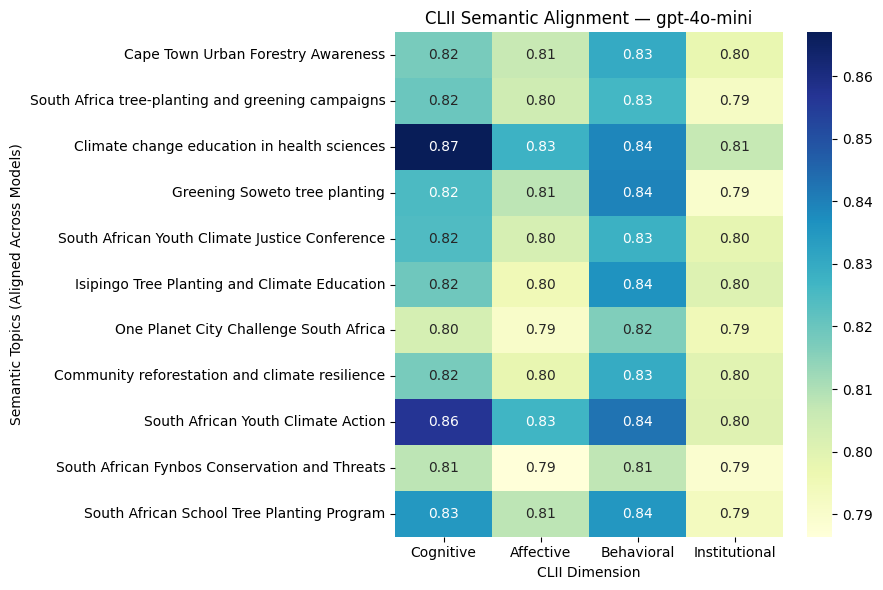

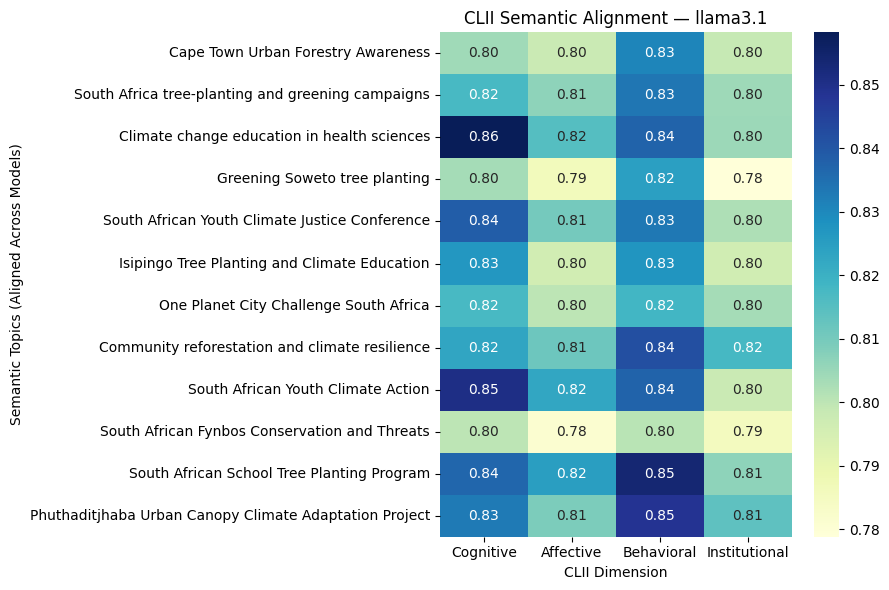

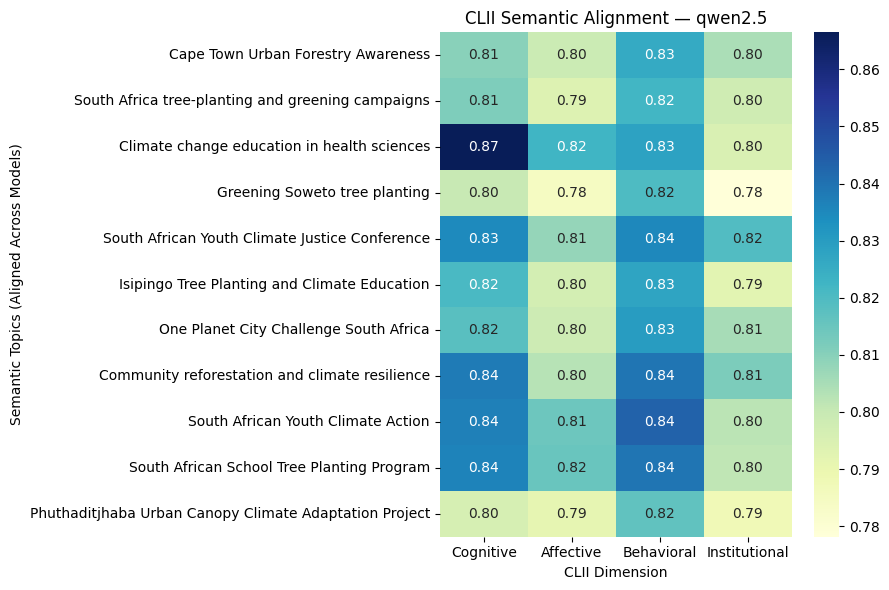

In [ ]:
for model_name, subset in clii_df.groupby("model"):
    plt.figure(figsize=(9,6))
    heat_df = subset.set_index("topic_label")[["Cognitive","Affective","Behavioral","Institutional"]]
    sns.heatmap(heat_df, annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title(f"CLII Semantic Alignment — {model_name}")
    plt.xlabel("CLII Dimension")
    plt.ylabel("Semantic Topics (Aligned Across Models)")
    plt.tight_layout()
    plt.show()


In [ ]:
fields = [dim for dim, phrases in clii_anchors.items()]
print(fields)

['Cognitive', 'Affective', 'Behavioral', 'Institutional']


In [ ]:
phrase_df.head()

,document_id,model,phrase,cluster,topic_label,sentiment,temporal
8,9,gpt-4o-mini,"Forest for Good. South African communities, sp...",10,South African School Tree Planting Program,positive,present
10,11,gpt-4o-mini,Not specified. South African coastal dune ecos...,9,South African Fynbos Conservation and Threats,positive,past
11,12,gpt-4o-mini,Not specified. South African ecosystems and co...,9,South African Fynbos Conservation and Threats,negative,present
12,13,gpt-4o-mini,Not specified. Undergraduate health sciences s...,2,Climate change education in health sciences,positive,present
13,14,gpt-4o-mini,TreeKeepers Cape Town. Cape Town communities. ...,0,Cape Town Urban Forestry Awareness,positive,present


In [ ]:
new_data_df = df_filtered[['summary', 'communities', 'project_name', 'time_frames', 'future_goals',
       'intervention_type', 'outcomes', 'impacts', 'interventions',
       'sa_project', 'climate_related', 'text', 'index', 'document_id',
       'model', 'error', 'raw', 'cognitive', 'affective', 'behavioral', 'institutional']]

In [ ]:
new_data_df.head(20)

,summary,communities,project_name,time_frames,future_goals,intervention_type,outcomes,impacts,interventions,sa_project,...,text,index,document_id,model,error,raw,cognitive,affective,behavioral,institutional
8,"In Gauteng, South Africa, a tree-planting init...","South African communities, specifically learne...",Forest for Good,Not specified,"To plant a total of 1,000 trees across 20 scho...",intervention-1,"Increased green spaces, improved air quality, ...","50 trees planted on launch day; total of 1,000...","YES, because the initiative involves tree plan...",YES,...,21-year-old South African setting the bar high...,14,9,gpt-4o-mini,NaN,NaN,NaN,NaN,NaN,NaN
10,The vegetation of calcareous coastal dunes of ...,South African coastal dune ecosystems,Not specified,Not specified,To afford the highest conservation priority to...,intervention-1,Increased understanding of vegetation composit...,Identification of six fynbos and two thicket c...,NO,YES,...,The vegetation of calcareous coastal dunes of ...,20,11,gpt-4o-mini,NaN,NaN,NaN,NaN,NaN,NaN
11,The document discusses the significant loss of...,South African ecosystems and communities,Not specified,2014–2018,Preventing further habitat degradation and los...,intervention-1,Informed decision-making in environmental and ...,Approximately 22% of natural habitat lost; inc...,NO,YES,...,The loss of natural habitat resulting from hum...,16,12,gpt-4o-mini,NaN,NaN,0.35,0.05,0.05,0.25
12,"The study focuses on the knowledge, perception...",Undergraduate health sciences students at the ...,Not specified,Not specified,Integrate planetary health and environmental s...,intervention-3,Increased awareness of the importance of clima...,264 respondents; 64.4% awareness of climate ch...,"YES, because the study highlights the need for...",YES,...,Background. Climate change and polluting healt...,3,13,gpt-4o-mini,NaN,NaN,NaN,NaN,NaN,NaN
13,TreeKeepers Cape Town is a citizen-based assoc...,Cape Town communities,TreeKeepers Cape Town,Not specified,To increase Cape Town’s urban tree canopy and ...,intervention-1,Increased community awareness and involvement ...,Not explicitly mentioned.,"YES, because the project promotes awareness an...",YES,...,TreeKeepers Cape Town is a citizen-based assoc...,8,14,gpt-4o-mini,NaN,NaN,0.80,0.60,0.65,0.10
14,The document discusses the critical role of tr...,South African communities and ecosystems,Food & Trees for Africa (FTFA),Not specified,To continue planting trees in appropriate biom...,intervention-1,Increased tree planting efforts and community ...,Over 4.6 million trees planted; annual plantin...,"YES, because the interventions focus on enhanc...",YES,...,Trees make communities and ecosystems more res...,4,15,gpt-4o-mini,NaN,NaN,0.70,0.65,0.90,0.60
15,The South African Wildlife College (SAWC) is a...,"local communities, conservation agencies, stud...",South African Wildlife College,Not specified,To inspire and train individuals to become con...,intervention-3,increased conservation awareness and skills am...,"over 23,000 people trained, involvement in 130...",NO,YES,...,Interested in studying at SAWC? Our mission as...,24,16,gpt-4o-mini,NaN,NaN,0.80,0.40,0.60,0.70
16,The document discusses a two-day conference or...,South African youth and vulnerable communities,Youth Climate Justice Conference,17 – 18 November 2022,To empower young activists and build a movemen...,intervention-3,Increased knowledge and tools for young activi...,Not specified,"YES, because the conference aims to empower yo...",YES,...,In collaboration with the Centre for Human Rig...,8,17,gpt-4o-mini,NaN,NaN,0.70,0.55,0.30,0.20
17,The text discusses the significant role of you...,South African youth and communities,South African Youth Climate Action Plan,Developed in 2021,To encourage youth-led action and guide stakeh...,intervention-3,Increased awareness and advocacy for climate a...,"Over 3600 responses in a climate survey, with ...","YES, because the interventions focus on educat...",YES,...,“Good 

In [ ]:
def llm_judge_sentiment_temporal(text, field_name):
    if not text or text.strip().lower() in ["not specified", "none"]:
      return {"sentiment": "neutral", "timeframe": "present"}

    prompt = f"""
    You are analyzing text extracted from a climate-related research article.
    The text is from the **{field_name}** section.

    Determine:
    1. Sentiment polarity: "positive", "negative", or "neutral"
    2. Temporal context: "past", "present", or "future"

    Respond strictly in JSON format, for example:
    {{
      "sentiment": "positive",
      "timeframe": "future"
    }}

    Text: "{text}"
    """

    try:
        messages = [{"role": "user", "content": prompt}]
        response = client.invoke(messages)
        return response.content.strip()
    except Exception:
        print(f"Error for {field_name}: {e}")
        return {"sentiment": "neutral", "timeframe": "present"}

In [ ]:
def safe_parse_response(response):
    """Ensure the LLM result is a dict with 'sentiment' and 'timeframe'."""
    if isinstance(response, dict):
        return response
    if isinstance(response, str):
        try:
            # try parsing JSON string
            return json.loads(response)
        except Exception:
            pass
    # fallback in case of error
    return {"sentiment": "neutral", "timeframe": "unspecified"}

In [ ]:
fields = ["interventions", "outcomes", "impacts", "time_frames", "future_goals"]
error_data = []
for field in tqdm(fields):
  try:

    print(f"Processing {field}...")
    results = new_data_df[field].apply(
        lambda x: safe_parse_response(llm_judge_sentiment_temporal(str(x), field))
    )

    new_data_df[f"{field}_sentiment"] = results.apply(lambda r: r.get("sentiment", "neutral"))
    new_data_df[f"{field}_timeframe"] = results.apply(lambda r: r.get("timeframe", "unspecified"))

  except Exception as e:
    error_data.append({"field": field, "error": str(e), "results": results})
    print(f"Error for {field}: {e}, results: {results}")
    continue

  0%|          | 0/5 [00:00<?, ?it/s]

Processing interventions...


/tmp/ipython-input-244326763.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_df[f"{field}_sentiment"] = results.apply(lambda r: r.get("sentiment", "neutral"))
/tmp/ipython-input-244326763.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_df[f"{field}_timeframe"] = results.apply(lambda r: r.get("timeframe", "unspecified"))
 20%|██        | 1/5 [02:01<08:07, 121.97s/it]

Processing outcomes...


 40%|████      | 2/5 [05:04<07:53, 157.87s/it]

...

 60%|██████    | 3/5 [07:42<05:15, 157.89s/it]

Processing time_frames...


 80%|████████  | 4/5 [08:59<02:05, 125.69s/it]

Processing future_goals...


100%|██████████| 5/5 [10:42<00:00, 128.43s/it]


In [ ]:
new_data_df.columns

Index(['summary', 'communities', 'project_name', 'time_frames', 'future_goals',
       'intervention_type', 'outcomes', 'impacts', 'interventions',
       'sa_project', 'climate_related', 'text', 'index', 'document_id',
       'model', 'error', 'raw', 'cognitive', 'affective', 'behavioral',
       'interventions_sentiment', 'interventions_timeframe',
       'outcomes_sentiment', 'outcomes_timeframe', 'impacts_sentiment',
       'impacts_timeframe', 'time_frames_sentiment', 'time_frames_timeframe',
       'future_goals_sentiment', 'future_goals_timeframe',
       'interventions_sentiment_num', 'interventions_timeframe_num',
       'outcomes_sentiment_num', 'outcomes_timeframe_num',
       'impacts_sentiment_num', 'impacts_timeframe_num',
       'time_frames_sentiment_num', 'time_frames_timeframe_num',
       'future_goals_sentiment_num', 'future_goals_timeframe_num'],
      dtype='object')

In [ ]:
fields = ["interventions", "outcomes", "impacts", "time_frames", "future_goals"]

for f in fields:
    new_data_df[f"{f}_combo"] = (
        new_data_df[f"{f}_sentiment"].astype(str)
        + "-"
        + new_data_df[f"{f}_timeframe"].astype(str)
    )


/tmp/ipython-input-93702356.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_df[f"{f}_combo"] = (
/tmp/ipython-input-93702356.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_df[f"{f}_combo"] = (
/tmp/ipython-input-93702356.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#r

In [ ]:
# new_data_df.to_excel('sentiment_for_interventions_by_clii.xlsx')
new_data_df.sample(n=15, random_state=42)

,summary,communities,project_name,time_frames,future_goals,intervention_type,outcomes,impacts,interventions,sa_project,...,impacts_timeframe_num,time_frames_sentiment_num,time_frames_timeframe_num,future_goals_sentiment_num,future_goals_timeframe_num,interventions_combo,outcomes_combo,impacts_combo,time_frames_combo,future_goals_combo
69,The document discusses the role of youth in cl...,"South African youth, schools, universities, or...","South African Youth Climate Action Plan, Frida...","2021, ongoing","Encourage youth-led action, guide transformati...",Intervention-3,Increased youth participation in climate activ...,"Over 120 climate protests, 3600 survey respons...","YES, the interventions focus on raising awaren...",YES,...,0,0,0,1,1,positive-present,positive-present,negative-present,neutral-present,positive-future
72,"The Department of Forestry, Fisheries and the ...","South African communities, particularly disadv...",National Arbor Month Campaign,"Annually from September 1st to 30th, with inte...",Planting two million trees annually as part of...,intervention-1,Increased awareness of the importance of trees...,"Promotion of indigenous tree planting, recogni...","YES, the campaign involves awareness and educa...",YES,...,0,0,-1,1,1,positive-present,positive-present,positive-present,neutral-past,positive-future
13,TreeKeepers Cape Town is a citizen-based assoc...,Cape Town communities,TreeKeepers Cape Town,Not specified,To increase Cape Town’s urban tree canopy and ...,intervention-1,Increased community awareness and involvement ...,Not explicitly mentioned.,"YES, because the project promotes awareness an...",YES,...,0,0,0,1,1,positive-present,positive-present,neutral-present,neutral-present,positive-future
25,"Three South African cities, Tshwane, Cape Town...","South African cities, specifically Tshwane, Ca...",One Planet City Challenge,Not specified,To drive the climate agenda forward and active...,intervention-3,Recognition of cities' leadership in climate a...,Increased participation from over 30 cities in...,"YES, because the initiative encourages cities ...",YES,...,0,0,0,1,1,positive-present,positive-present,positive-present,neutral-present,positive-future
65,TreeKeepers Cape Town is a voluntary associati...,"South African communities, specifically in Cap...",TreeKeepers Cape Town,Not specified,"Increase Cape Town’s urban tree canopy, contin...",intervention-1,"Increased awareness and appreciation of trees,...","Not specified quantitatively, but qualitativel...","YES, the project aligns with SDG 13.3 by enhan...",YES,...,-1,0,0,1,1,positive-present,positive-present,positive-past,neutral-present,positive-future
51,"The City of Tshwane, City of Cape Town, and eT...",South African cities,One Planet City Challenge,Not specified,"To drive the climate agenda forward, both in S...",Intervention-3,"Ambitious climate targets, bold leadership, an...",Not specified,"YES, as it aligns with the goal of limiting gl...",YES,...,0,0,0,1,1,positive-present,positive-future,neutral-present,neutral-present,positive-future
15,The South African Wildlife College (SAWC) is a...,"local communities, conservation agencies, stud...",South African Wildlife College,Not specified,To inspire and train individuals to become con...,intervention-3,increased conservation awareness and skills am...,"over 23,000 people trained, involvement in 130...",NO,YES,...,-1,0,0,1,1,negative-present,positive-past,positive-past,neutral-present,positive-future
59,The document discusses the implementation of u...,"Phuthaditjhaba, a town in South Africa",Urban Canopy Project,Within 20 years,To create a substantial tree canopy in Phuthad...,intervention-1,Enhanced urban green spaces and improved envir...,Not specified,NO,YES,...,0,0,1,1,1,negative-present,positive-present,neutral-present,neutral-future,positive-future
46,"The Department of Forestry, Fisheries and the ...","South African communities, especially disadvan...","National Arbor Month campaign, Two Million 

In [ ]:
clii_map = {
    "interventions": "Behavioral",
    "outcomes": "Cognitive",
    "impacts": "Affective",
    "time_frames": "Institutional",
    "future_goals": "Cognitive"
}


In [ ]:
import pandas as pd

melted = new_data_df.melt(
    value_vars=[f"{f}_combo" for f in fields],
    var_name="field",
    value_name="sentiment_intent"
)

melted["field"] = melted["field"].str.replace("_combo", "")
melted["CLII"] = melted["field"].map(clii_map)

heatmap_data = (
    melted.groupby(["CLII", "sentiment_intent"])
    .size()
    .reset_index(name="count")
    .pivot(index="CLII", columns="sentiment_intent", values="count")
    .fillna(0)
)


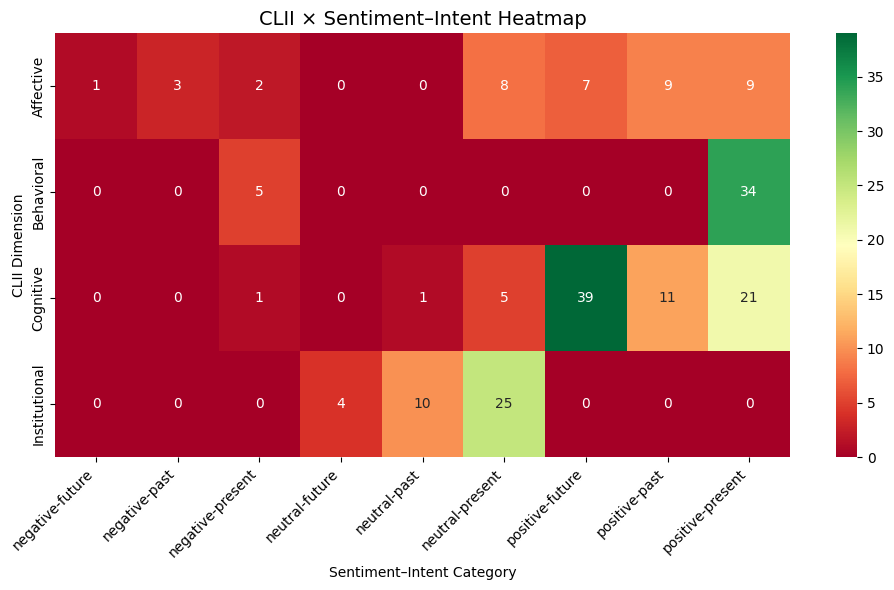

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap="RdYlGn", fmt=".0f")
plt.title("CLII × Sentiment–Intent Heatmap", fontsize=14)
plt.xlabel("Sentiment–Intent Category")
plt.ylabel("CLII Dimension")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
qwen_df = new_data_df[new_data_df['model']=='qwen2.5']
qwen_df.head()

,summary,communities,project_name,time_frames,future_goals,intervention_type,outcomes,impacts,interventions,sa_project,...,impacts_timeframe_num,time_frames_sentiment_num,time_frames_timeframe_num,future_goals_sentiment_num,future_goals_timeframe_num,interventions_combo,outcomes_combo,impacts_combo,time_frames_combo,future_goals_combo
59,The document discusses the implementation of u...,"Phuthaditjhaba, a town in South Africa",Urban Canopy Project,Within 20 years,To create a substantial tree canopy in Phuthad...,intervention-1,Enhanced urban green spaces and improved envir...,Not specified,NO,YES,...,0,0,1,1,1,negative-present,positive-present,neutral-present,neutral-future,positive-future
60,"P&G, in partnership with Food & Trees For Afri...","Learners and communities in Gauteng, South Africa",Forest for Good,"Started on Friday, March 15, and will continue...",Plant 1000 trees across 20 schools in selected...,intervention-1,"Increased awareness of environmental issues, c...","50 trees planted on the launch day, 1000 trees...","YES, the initiative includes awareness and edu...",YES,...,1,0,1,1,1,positive-present,positive-present,positive-future,neutral-future,positive-future
64,"The study assesses the knowledge, perceptions,...",Undergraduate health sciences students at the ...,Assessment of Climate Change and Environmental...,Not specified,Integrate planetary health and environmental s...,Intervention-3,Increased recognition of the importance of tea...,Two-thirds of respondents believed that climat...,YES. The study emphasizes the need for educati...,YES,...,1,0,0,1,1,positive-present,positive-present,negative-future,neutral-present,positive-future
65,TreeKeepers Cape Town is a voluntary associati...,"South African communities, specifically in Cap...",TreeKeepers Cape Town,Not specified,"Increase Cape Town’s urban tree canopy, contin...",intervention-1,"Increased awareness and appreciation of trees,...","Not specified quantitatively, but qualitativel...","YES, the project aligns with SDG 13.3 by enhan...",YES,...,-1,0,0,1,1,positive-present,positive-present,positive-past,neutral-present,positive-future
66,The document discusses the importance of trees...,"South African communities, ecosystems, and biomes",Food & Trees for Africa (FTFA),"FTFA has been active for 30 years, planting tr...",Continue planting trees in appropriate biomes ...,intervention-1,"Increased carbon sequestration, improved water...","Over 4.6 million trees planted, annual plantin...",YES. The emphasis on education and awareness a...,YES,...,0,0,0,1,1,positive-present,positive-present,positive-present,neutral-present,positive-future


In [ ]:
merged_df.to_excel('sentiment_for_interventions_by_clii_merged.xlsx')

In [ ]:
import pandas as pd

fields = ["interventions", "outcomes", "impacts", "time_frames", "future_goals"]

# Melt both sentiment and timeframe columns
sentiment_cols = [f"{f}_sentiment" for f in fields]
timeframe_cols = [f"{f}_timeframe" for f in fields]

# qwen_df = new_data_df[new_data_df['model']=='gpt-4o-mini']

sentiment_df = new_data_df[sentiment_cols].melt(var_name="field", value_name="sentiment")
timeframe_df = new_data_df[timeframe_cols].melt(var_name="field", value_name="timeframe")

# Normalize names to match
sentiment_df["field"] = sentiment_df["field"].str.replace("_sentiment", "")
timeframe_df["field"] = timeframe_df["field"].str.replace("_timeframe", "")

# Merge sentiment and timeframe info
merged_df = sentiment_df.copy()
merged_df["timeframe"] = timeframe_df["timeframe"]
merged_df["CLII"] = merged_df["field"].map(clii_map)
merged_df["sentiment_intent"] = merged_df["sentiment"].astype(str) + "-" + merged_df["timeframe"].astype(str)


In [ ]:
plt.figure(figsize=(12, max(4, 0.5*len(presence_matrix))))
sns.heatmap(
    presence_matrix.astype(int),
    cmap="YlOrRd",
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Number of Papers Mentioning Concept"}
)
plt.title("Distribution of Interventions, Outcomes, and Impacts across Clusters")
plt.xlabel("Classes")
plt.ylabel("Cluster (Climate Concept)")
plt.tight_layout()
plt.show()

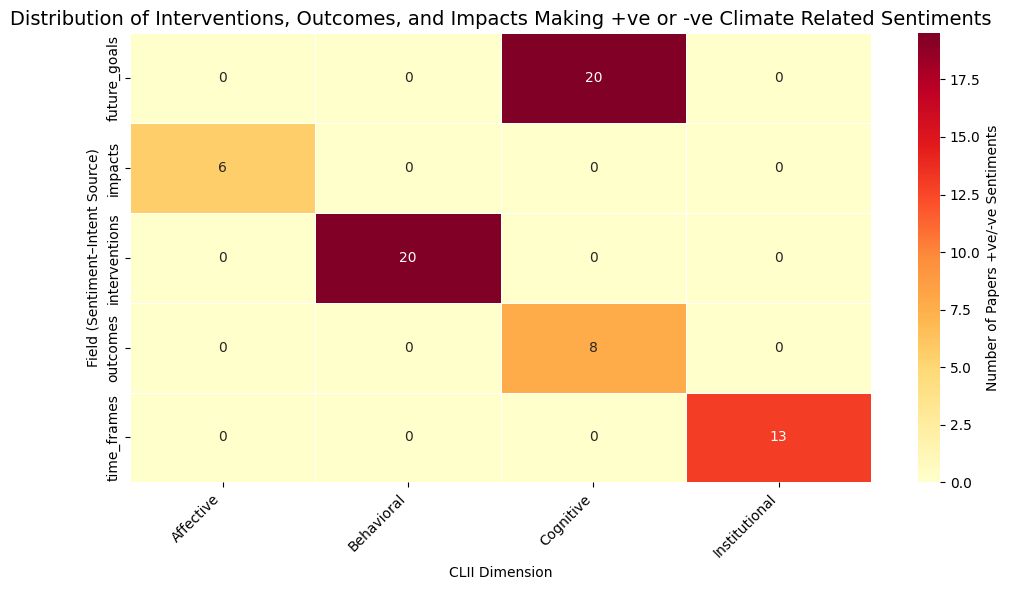

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count occurrences
heatmap_data = (
    merged_df.groupby(["field", "CLII", "sentiment_intent"])
    .size()
    .reset_index(name="count")
)

# Pivot for heatmap
heatmap_matrix = heatmap_data.pivot_table(
    index="field",
    columns="CLII",
    values="count",
    fill_value=0
)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_matrix, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5,
    cbar_kws={"label": "Number of Papers +ve/-ve Sentiments"})
plt.title("Distribution of Interventions, Outcomes, and Impacts Making +ve or -ve Climate Related Sentiments", fontsize=14)
plt.xlabel("CLII Dimension")
plt.ylabel("Field (Sentiment–Intent Source)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
heatmap_matrix = heatmap_matrix.div(heatmap_matrix.sum(axis=1), axis=0) * 100


In [ ]:
# clii_scores = []
# for (model_name, cluster_id), group in phrase_df.groupby(["model", "cluster"]):
#     mean_text = " ".join(group["phrase"].tolist())
#     scores = get_clii_scores(mean_text)
#     scores["model"] = model_name
#     scores["topic_label"] = group["topic_label"].iloc[0]
#     clii_scores.append(scores)

# clii_df = pd.DataFrame(clii_scores)

In [ ]:
sentiment_map = {"positive": 1, "neutral": 0, "negative": -1}
timeframe_map = {"past": -1, "present": 0, "future": 1, "unspecified": 0}

for field in ["interventions", "outcomes", "impacts", "time_frames", "future_goals"]:
    new_data_df[f"{field}_sentiment_num"] = new_data_df[f"{field}_sentiment"].map(sentiment_map)
    new_data_df[f"{field}_timeframe_num"] = new_data_df[f"{field}_timeframe"].map(timeframe_map)


/tmp/ipython-input-13949581.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_df[f"{field}_sentiment_num"] = new_data_df[f"{field}_sentiment"].map(sentiment_map)
/tmp/ipython-input-13949581.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_df[f"{field}_timeframe_num"] = new_data_df[f"{field}_timeframe"].map(timeframe_map)
/tmp/ipython-input-13949581.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [ ]:
new_data_df.head()

,summary,communities,project_name,time_frames,future_goals,intervention_type,outcomes,impacts,interventions,sa_project,...,text,index,document_id,model,error,raw,cognitive,affective,behavioral,institutional
8,"In Gauteng, South Africa, a tree-planting init...","South African communities, specifically learne...",Forest for Good,Not specified,"To plant a total of 1,000 trees across 20 scho...",intervention-1,"Increased green spaces, improved air quality, ...","50 trees planted on launch day; total of 1,000...","YES, because the initiative involves tree plan...",YES,...,21-year-old South African setting the bar high...,14,9,gpt-4o-mini,NaN,NaN,NaN,NaN,NaN,NaN
10,The vegetation of calcareous coastal dunes of ...,South African coastal dune ecosystems,Not specified,Not specified,To afford the highest conservation priority to...,intervention-1,Increased understanding of vegetation composit...,Identification of six fynbos and two thicket c...,NO,YES,...,The vegetation of calcareous coastal dunes of ...,20,11,gpt-4o-mini,NaN,NaN,NaN,NaN,NaN,NaN
11,The document discusses the significant loss of...,South African ecosystems and communities,Not specified,2014–2018,Preventing further habitat degradation and los...,intervention-1,Informed decision-making in environmental and ...,Approximately 22% of natural habitat lost; inc...,NO,YES,...,The loss of natural habitat resulting from hum...,16,12,gpt-4o-mini,NaN,NaN,0.35,0.05,0.05,0.25
12,"The study focuses on the knowledge, perception...",Undergraduate health sciences students at the ...,Not specified,Not specified,Integrate planetary health and environmental s...,intervention-3,Increased awareness of the importance of clima...,264 respondents; 64.4% awareness of climate ch...,"YES, because the study highlights the need for...",YES,...,Background. Climate change and polluting healt...,3,13,gpt-4o-mini,NaN,NaN,NaN,NaN,NaN,NaN
13,TreeKeepers Cape Town is a citizen-based assoc...,Cape Town communities,TreeKeepers Cape Town,Not specified,To increase Cape Town’s urban tree canopy and ...,intervention-1,Increased community awareness and involvement ...,Not explicitly mentioned.,"YES, because the project promotes awareness an...",YES,...,TreeKeepers Cape Town is a citizen-based assoc...,8,14,gpt-4o-mini,NaN,NaN,0.80,0.60,0.65,0.10


In [ ]:
# Define your y-axis categories
category_map = {
    "interventions": "Interventions",
    "outcomes": "Outcomes",
    "impacts": "Impacts",
    "future_goals": "Future Plans"
}

# Build a long-form table
records = []
for field in fields:
    for _, row in new_data_df.iterrows():
        category = category_map.get(field, field)
        records.append({
            "Category": f"{row[f'{field}_sentiment'].capitalize()} {category}",
            "Cognitive": row.get("cognitive"),
            "Affective": row.get("affective"),
            "Behavioral": row.get("behavioral"),
            "Institutional": row.get("institutional")
        })

heatmap_df = pd.DataFrame(records)
clii_heatmap_df = heatmap_df.groupby("Category")[["Cognitive","Affective","Behavioral","Institutional"]].mean().reset_index()


TypeError: Image data of dtype object cannot be converted to float

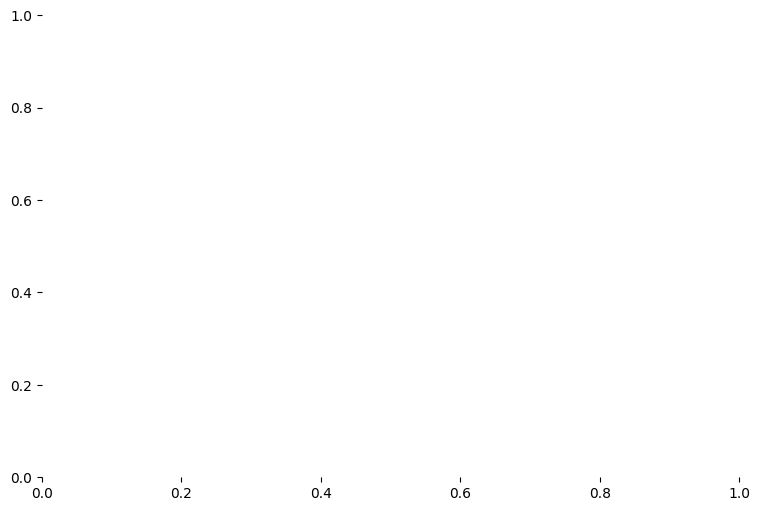

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))
sns.heatmap(
    clii_heatmap_df.set_index("Category"),
    annot=True, cmap="RdYlGn", fmt=".2f", linewidths=0.5
)
plt.title("CLII Semantic Alignment by Sentiment and Temporal Intent (LLM-Assessed)")
plt.xlabel("CLII Dimension")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


In [ ]:
import json
import pandas as pd

def parse_llm_result(res):
    try:
        r = json.loads(res)
        return pd.Series([r["sentiment"], r["timeframe"]])
    except:
        return pd.Series(["neutral","present"])

phrase_df[["sentiment","temporal"]] = phrase_df["phrase"].apply(
    lambda x: parse_llm_result(llm_sentiment_temporal(x))
)


NameError: name 'llm_sentiment_temporal' is not defined

In [ ]:
phrase_df.head()

,document_id,model,phrase,cluster,topic_label,sentiment,temporal
8,9,gpt-4o-mini,"Forest for Good. South African communities, sp...",10,South African School Tree Planting Program,positive,present
10,11,gpt-4o-mini,Not specified. South African coastal dune ecos...,9,South African Fynbos Conservation and Threats,positive,past
11,12,gpt-4o-mini,Not specified. South African ecosystems and co...,9,South African Fynbos Conservation and Threats,negative,present
12,13,gpt-4o-mini,Not specified. Undergraduate health sciences s...,2,Climate change education in health sciences,positive,present
13,14,gpt-4o-mini,TreeKeepers Cape Town. Cape Town communities. ...,0,Cape Town Urban Forestry Awareness,positive,present


In [ ]:
def categorize(row):
    if row["field"].lower() == "intervention":
        return f"{row['sentiment'].capitalize()} Interventions"
    elif row["field"].lower() == "outcome":
        return f"{row['sentiment'].capitalize()} Outcomes"
    elif row["temporal"] == "future":
        return f"{row['sentiment'].capitalize()} Future Plans"
    else:
        return None

phrase_df["Category"] = phrase_df.apply(categorize, axis=1)


KeyError: 'field'

In [ ]:
clii_heatmap_df = (
    phrase_df.groupby("Category")[["Cognitive","Affective","Behavioral","Institutional"]]
    .mean()
    .reset_index()
)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    clii_heatmap_df.set_index("Category"),
    annot=True, cmap="RdYlGn", fmt=".2f", linewidths=0.5
)
plt.title("LLM-Judged CLII Semantic Alignment by Sentiment and Intent")
plt.xlabel("CLII Dimension")
plt.ylabel("Category (Interventions / Outcomes / Future Plans)")
plt.tight_layout()
plt.show()


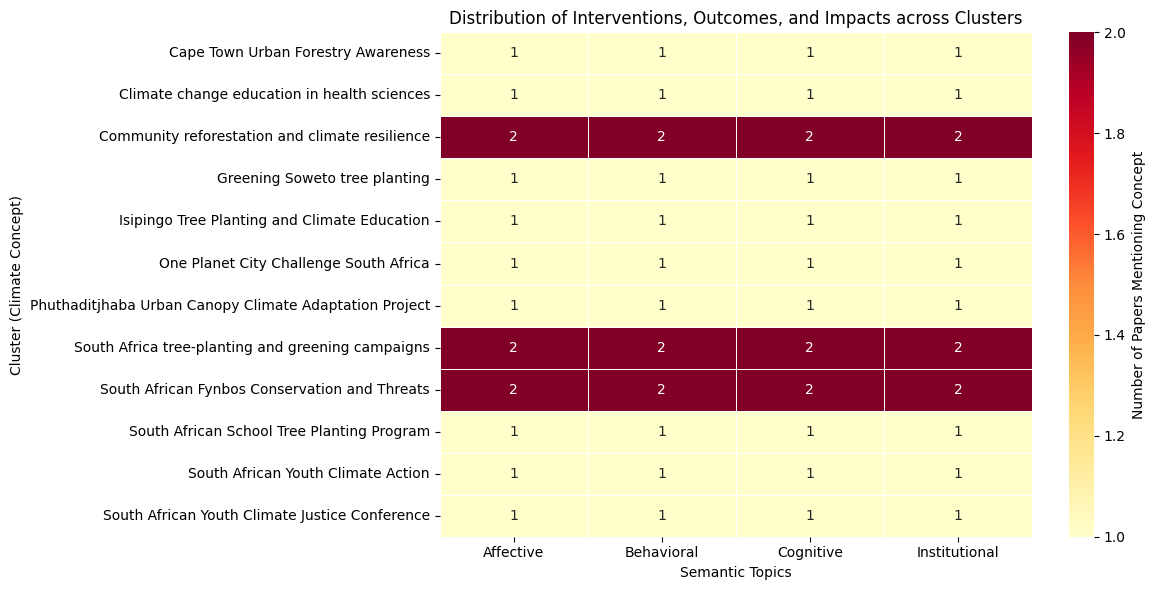

NameError: name 'presence_norm' is not defined

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import plotly.graph_objects as go

# Example re-create (skip if you already have these)
presence = ( new_phrase_df.groupby(["topic_label","field"])["document_id"].nunique().reset_index(name="doc_count") )
presence_matrix = presence.pivot_table(index='topic_label', columns='field', values='doc_count', fill_value=0)


threshold = 0.60   # choose what you consider "strong alignment"

# --------------------------------
# 7️⃣ Visualize Heatmaps
# --------------------------------
plt.figure(figsize=(12, max(4, 0.5*len(presence_matrix))))
sns.heatmap(
    presence_matrix.astype(int),
    cmap="YlOrRd",
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Number of Papers Mentioning Concept"}
)
plt.title("Distribution of Interventions, Outcomes, and Impacts across Clusters")
plt.xlabel("Semantic Topics")
plt.ylabel("Cluster (Climate Concept)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, max(4, 0.5*len(presence_norm))))
sns.heatmap(
    presence_norm,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Proportion of Mentions per Cluster"}
)
plt.title("Relative Representation of Evidence across Classes")
plt.xlabel("Classes")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [ ]:
# Average CLII alignment across all topics for each model
model_summary = (
    clii_df
    .groupby("model")[["Cognitive", "Affective", "Behavioral", "Institutional"]]
    .mean()
    .reset_index()
)


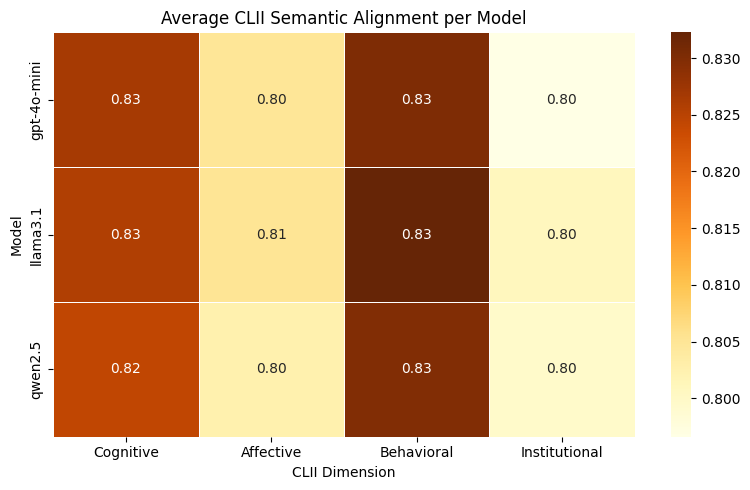

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    model_summary.set_index("model"),
    annot=True,
    cmap="YlOrBr",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Average CLII Semantic Alignment per Model")
plt.xlabel("CLII Dimension")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


In [ ]:
df_test.columns

Index(['Unnamed: 0', 'summary', 'communities', 'project_name', 'time_frames',
       'future_goals', 'intervention_type', 'outcomes', 'impacts',
       'interventions', 'sa_project', 'climate_related', 'text', 'index',
       'document_id', 'model', 'error', 'raw', 'cognitive', 'affective',
       'behavioral', 'interventions_sentiment', 'interventions_timeframe',
       'outcomes_sentiment', 'outcomes_timeframe', 'impacts_sentiment',
       'impacts_timeframe', 'time_frames_sentiment', 'time_frames_timeframe',
       'future_goals_sentiment', 'future_goals_timeframe'],
      dtype='object')

In [ ]:
df_test[['interventions','outcomes', 'impacts','time_frames','future_goals', 'interventions_sentiment', 'interventions_timeframe']].sample(n=10)

,interventions,outcomes,impacts,time_frames,future_goals,interventions_sentiment,interventions_timeframe
2,NO,Informed decision-making in environmental and ...,Approximately 22% of natural habitat lost; inc...,2014–2018,Preventing further habitat degradation and los...,negative,present
11,"YES, because it promotes awareness and educati...",Increased awareness of the importance of trees...,Target of planting at least two million trees ...,Annual campaign from September 1-30; ongoing i...,Planting two million trees annually and achiev...,positive,present
22,"YES, as it promotes climate action through tre...",Increased awareness about the importance of tr...,Planting of at least two million trees annuall...,Not specified,"Planting at least two million trees annually, ...",positive,present
28,"YES, the initiative includes awareness and edu...","Increased awareness of environmental issues, c...","50 trees planted on the launch day, 1000 trees...","Started on Friday, March 15, and will continue...",Plant 1000 trees across 20 schools in selected...,positive,present
21,"YES, as it involves awareness and education ef...","Raised awareness, educated youth, encouraged y...",Over 14 million people joined the Fridays for ...,"2018, 2021, Not specified",Not specified,positive,present
24,"YES, as it promotes climate action through tre...",Increased awareness about the importance of tr...,Planting of at least two million trees annuall...,Not specified,"Planting at least two million trees annually, ...",positive,present
31,YES. The emphasis on education and awareness a...,"Increased carbon sequestration, improved water...","Over 4.6 million trees planted, annual plantin...","FTFA has been active for 30 years, planting tr...",Continue planting trees in appropriate biomes ...,positive,present
23,"YES, as it involves climate change mitigation ...",Creation of a sustainable outdoor classroom an...,"63,429 trees planted, offsetting an estimated ...",Not specified,To continue promoting environmental education ...,positive,present
10,"YES, the initiative aligns with SDG 13.3 by pr...",Improved atmosphere and health conditions at t...,"50 trees planted, 63,429 trees planted since 2...",Not specified,To continue educating learners on tree care an...,positive,present
33,"YES, the interventions focus on raising awaren...",Increased youth participation in climate activ...,"Over 120 climate protests, 3600 survey respons...","2021, ongoing","Encourage youth-led action, guide transformati...",positive,present


In [ ]:
xx['interventions'].to_list()[0]

'YES, the initiative includes awareness and education efforts through curriculum development and community engagement'

In [ ]:
df_test['communities'].to_list()

['South African communities, specifically learners at Thobeka Primary School in Soweto, Gauteng.',
 'South African coastal dune ecosystems',
 'South African ecosystems and communities',
 'Undergraduate health sciences students at the University of Cape Town, South Africa',
 'Cape Town communities',
 'South African communities and ecosystems',
 'local communities, conservation agencies, students',
 'South African youth and vulnerable communities',
 'South African youth and communities',
 'South African communities, particularly disadvantaged areas',
 'Isipingo community, Durban, KwaZulu-Natal, South Africa',
 'South African communities, particularly disadvantaged areas',
 'Soweto, South Africa',
 'South African cities, specifically Tshwane, Cape Town, and eThekwini Metropolitan Municipality',
 'Phuthaditjhaba community',
 'South African communities, schools, and learners',
 'Cape Floristic Region, ecosystems',
 'Undergraduate health sciences students at the University of Cape Town',
 'C

In [ ]:
df_test = pd.read_excel("sentiment_for_interventions_by_clii (1).xlsx")
"""
 'project_name', 'time_frames',
       'future_goals', 'intervention_type', 'outcomes', 'impacts',
       'interventions', 'sa_project', 'climate_related', 'text', 'index',
       'document_id', 'model', 'error', 'raw',
"""
# df_test[['project_name','interventions', 'communities', 'interventions_sentiment', 'interventions_timeframe',
#        'outcomes_sentiment', 'outcomes_timeframe', 'impacts_sentiment',
#        'impacts_timeframe', 'time_frames_sentiment', 'time_frames_timeframe',
#        'future_goals_sentiment', 'future_goals_timeframe']]
df_test[df_test['interventions_sentiment'] == 'positive']['outcomes'].to_list()

['Increased green spaces, improved air quality, and educational opportunities for students.',
 'Increased awareness of the importance of climate change and environmental sustainability among health sciences students',
 'Increased community awareness and involvement in tree conservation.',
 'Increased tree planting efforts and community involvement in climate action.',
 'Increased knowledge and tools for young activists to influence climate justice.',
 'Increased awareness and advocacy for climate action among youth.',
 'Increased awareness of the importance of trees and enhanced community participation in greening efforts',
 'Improved atmosphere and health conditions at the school, increased community engagement in sustainability.',
 'Increased awareness of the importance of trees and enhanced community participation in greening efforts',
 'Improved urban environment',
 "Recognition of cities' leadership in climate action and commitment to ambitious climate targets.",
 'Creation of a t

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

100%|██████████| 39/39 [00:04<00:00,  8.53it/s]


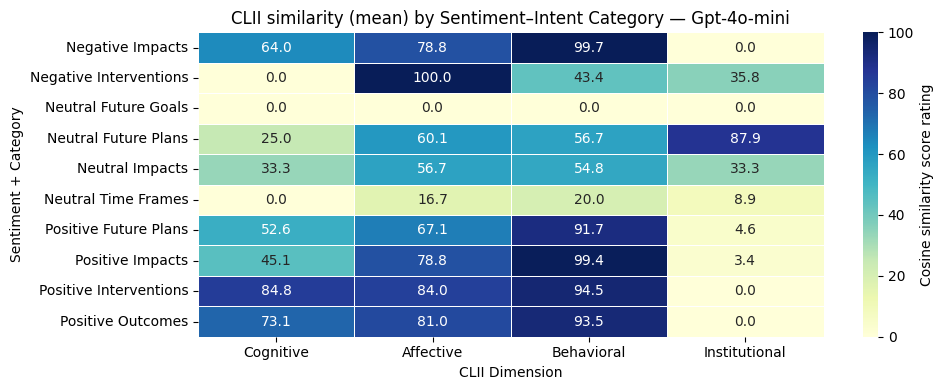

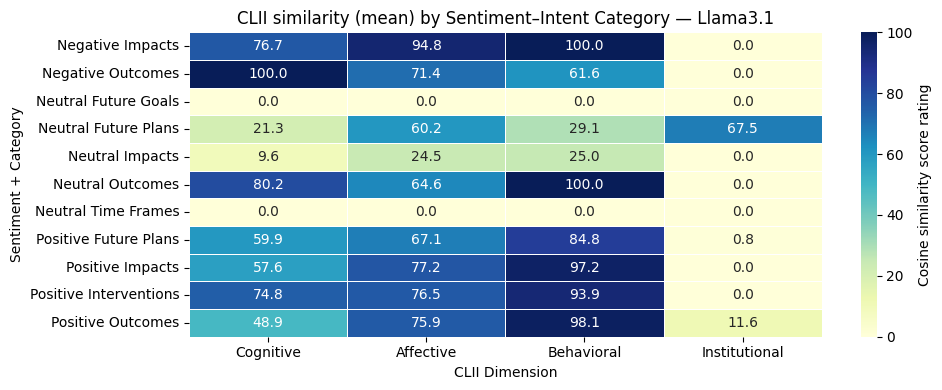

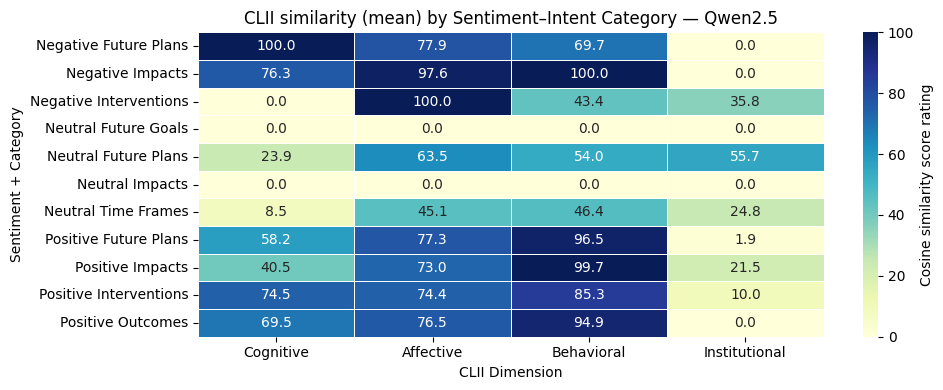

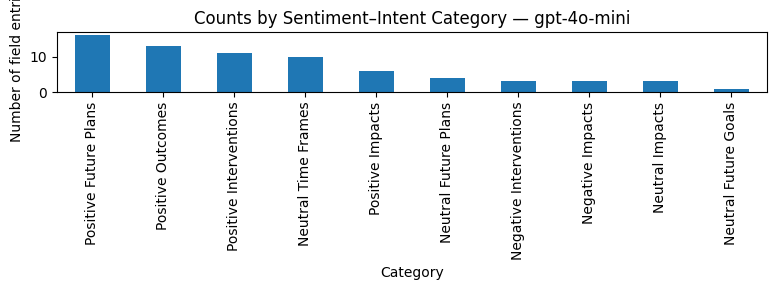

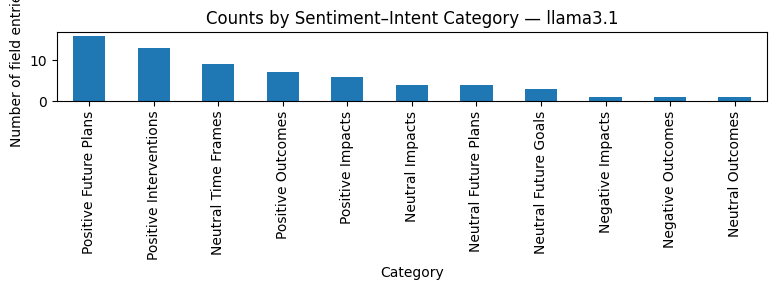

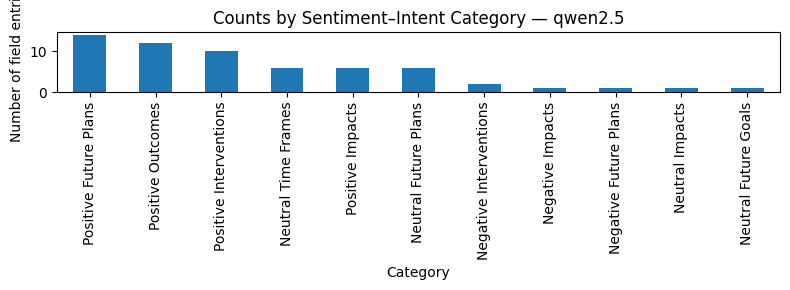

In [ ]:
# Requirements:
# pip install sentence-transformers seaborn matplotlib tqdm

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# ------------- Load your dataframe -------------
# replace with your file load if needed
# df_test = pd.read_excel("sentiment_for_interventions_by_clii.xlsx")
df_test = pd.read_excel("sentiment_for_interventions_by_clii (1).xlsx")
# df_test = new_data_df.copy()   # your dataframe that already has sentiment/timeframe cols

# Check required columns exist
fields = ["interventions", "outcomes", "impacts", "time_frames", "future_goals"]
for f in fields:
    assert f in df_test.columns, f"Missing {f}"
    assert f"{f}_sentiment" in df_test.columns and f"{f}_timeframe" in df_test.columns, \
        f"Missing sentiment/timeframe columns for {f}"

# Optional: ensure model column exists if you want per-model plots
if "model" not in df_test.columns:
    df_test["model"] = "all_models"

# ------------- Prepare CLII anchor phrases -------------
clii_anchors = {
    "Cognitive": "knowledge, awareness, understanding of climate change and climate literacy",
    "Affective": "emotional engagement, concern, motivation, attitudes toward climate action",
    "Behavioral": "actions, practices, participation, adoption of climate mitigation/adaptation behaviors",
    "Institutional": "policy, curriculum, governance, institutional integration and capacity building"
}

# ------------- Embed anchors and texts -------------
st_model = SentenceTransformer("all-MiniLM-L6-v2")  # fast & good
anchor_texts = list(clii_anchors.values())
anchor_names = list(clii_anchors.keys())
anchor_embs = st_model.encode(anchor_texts, convert_to_tensor=True)

# helper to compute similarity vector (Cognitive..Institutional) for a piece of text
def clii_similarity_vector(text):
    if not isinstance(text, str) or text.strip() == "" or text.strip().lower() in ["none","not specified","nan"]:
        return {k: 0.0 for k in anchor_names}
    emb = st_model.encode(text, convert_to_tensor=True)
    sims = util.cos_sim(emb, anchor_embs).cpu().numpy().flatten()  # length = 4
    # normalize to 0-1 (cosine similarity is approx -1..1 but for SBERT usually 0..1)
    # we'll clip and rescale to 0..1 just in case
    sims = np.clip(sims, -1, 1)
    sims = (sims - sims.min()) / (sims.max() - sims.min() + 1e-12) if sims.max() != sims.min() else sims
    return dict(zip(anchor_names, sims))

# ------------- Build long table: one row per original row × field -------------
rows = []
for idx, row in tqdm(df_test.iterrows(), total=len(df_test)):
    for f in fields:
        text = row.get(f, "")
        # compute CLII similarity vector
        sim = clii_similarity_vector(str(text))
        sentiment = str(row.get(f"{f}_sentiment", "neutral")).lower()
        timeframe = str(row.get(f"{f}_timeframe", "present")).lower()
        category = f"{sentiment.capitalize()} {f.replace('_',' ').title()}" if timeframe == "present" else f"{sentiment.capitalize()} {('Future Plans' if f in ['future_goals','time_frames'] or timeframe=='future' else f.replace('_',' ').title())}"
        rows.append({
            "document_id": row.get("document_id", idx),
            "model": row.get("model", "all_models"),
            "field": f,
            "category": category,
            "text": text,
            "sentiment": sentiment,
            "timeframe": timeframe,
            **sim
        })

long_df = pd.DataFrame(rows)

# ------------- Aggregation choices -------------
# Option A: Mean CLII similarity per category × CLII dimension (recommended)
agg_mean = long_df.groupby(["model","category"])[anchor_names].mean().reset_index()

# Option B: Count of items per category (for frequencies)
agg_count = long_df.groupby(["model","category"]).size().reset_index(name="count")
# long_df.to_csv("clii_score_post.csv")
# ------------- Plot per-model heatmaps (CLII values) -------------
models = agg_mean['model'].unique()
for model_name in models:
    sub = agg_mean[agg_mean['model'] == model_name].set_index('category')
    # reorder rows if you want specific ordering
    if sub.shape[0] == 0:
        continue
    plt.figure(figsize=(10, max(4, 0.35*sub.shape[0])))
    sns.heatmap(sub[anchor_names] * 100, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.4,
                    cbar_kws={"label": "Cosine similarity score rating"})
    # sns.heatmap(sub[anchor_names], annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.4)
    plt.title(f"CLII similarity (mean) by Sentiment–Intent Category — {model_name.capitalize()}")
    plt.xlabel("CLII Dimension")
    plt.ylabel("Sentiment + Category")
    plt.tight_layout()
    plt.show()

# ------------- Optional: plot counts per category (side-by-side) -------------
for model_name in models:
    subc = agg_count[agg_count['model'] == model_name].set_index('category')
    if subc.shape[0] == 0:
        continue
    plt.figure(figsize=(8, max(3,0.25*subc.shape[0])))
    subc['count'].sort_values(ascending=False).plot(kind='bar')
    plt.title(f"Counts by Sentiment–Intent Category — {model_name}")
    plt.ylabel("Number of field entries")
    plt.xlabel("Category")
    plt.tight_layout()
    plt.show()


In [ ]:
.columns#['communities']

NameError: name 'test_df' is not defined

In [ ]:

# long_df.columns
qwen_df = long_df[(long_df['model'] =='qwen2.5') & (long_df['sentiment'] =='positive') & (long_df['timeframe']=='future')]
qwen_df['text'].to_list()
# long_df[(long_df['model'] =='qwen2.5') & ((long_df['category'] == 'Positive Future Plans') | (long_df['category'] == 'Negative Future Plans'))][['document_id', 'model', 'field', 'category', 'text', 'sentiment','timeframe', 'Cognitive', 'Affective', 'Behavioral', 'Institutional']].to_excel("future_plans.xlsx")

['To create a substantial tree canopy in Phuthaditjhaba',
 '50 trees planted on the launch day, 1000 trees to be planted in total, estimated offset of 369 tonnes of carbon dioxide, improved community knowledge and resilience',
 'Plant 1000 trees across 20 schools in selected communities in Gauteng, improve environmental education, and increase biodiversity',
 'Integrate planetary health and environmental sustainability into the curricula of the Faculty of Health Sciences at the University of Cape Town.',
 'Increase Cape Town’s urban tree canopy, continue to promote the value of trees, empower citizens, and build community engagement',
 'Continue planting trees in appropriate biomes and urban areas, ensuring the use of indigenous species',
 'Improved capacity of youth to articulate their interests and rights in climate policy-making processes',
 'To build a vibrant and informed youth movement in South Africa that can influence climate justice and policy-making processes.',
 'Encourage y

               Cognitive  Affective  Behavioral  Institutional
field                                                         
future_goals    0.547692   0.729124    0.962813       0.024769
impacts         0.505549   0.798119    0.988490       0.143631
interventions   0.745346   0.743633    0.852900       0.100000
outcomes        0.694664   0.765354    0.948969       0.000000
               Cognitive  Affective  Behavioral  Institutional
field                                                         
impacts         0.881398    0.87753    0.848250        0.00000
interventions   0.000000    1.00000    0.434202        0.35789


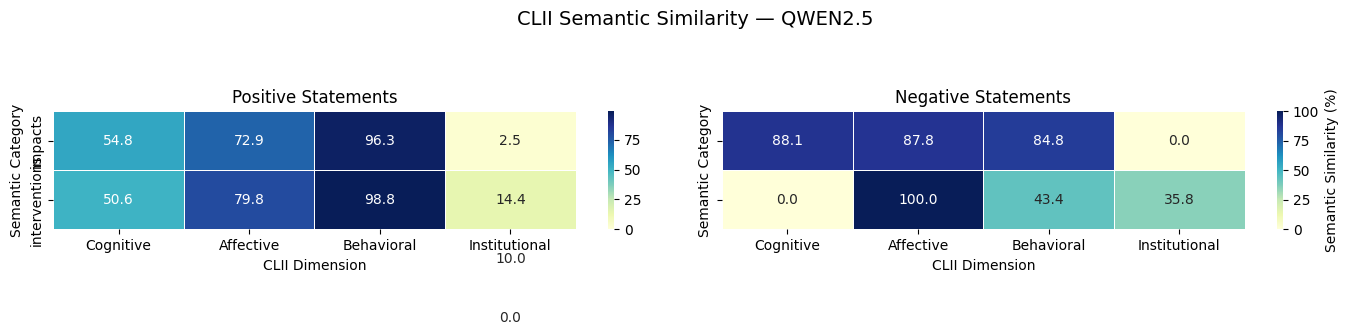

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure you have CLII columns
clii_columns = ["Cognitive", "Affective", "Behavioral", "Institutional"]

# Loop through models
for model_name in long_df["model"].unique():
    sub_df = long_df[long_df["model"] == model_name]

    # Create subplots for positive and negative
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, sentiment in enumerate(["positive", "negative"]):
    sub = qwen_df[qwen_df["sentiment"] == sentiment]
    mean_df = sub.groupby("field")[clii_columns].mean().sort_index()
    print(mean_df)
    sns.heatmap(mean_df * 100, annot=True, fmt=".1f", cmap="YlGnBu",
                linewidths=0.4, ax=axes[i],
                cbar_kws={"label": "Semantic Similarity (%)"} if i == 1 else None)
    axes[i].set_title(f"{sentiment.capitalize()} Statements")
    axes[i].set_xlabel("CLII Dimension")
    axes[i].set_ylabel("Semantic Category")

plt.suptitle(f"CLII Semantic Similarity — {model_name.upper()}", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


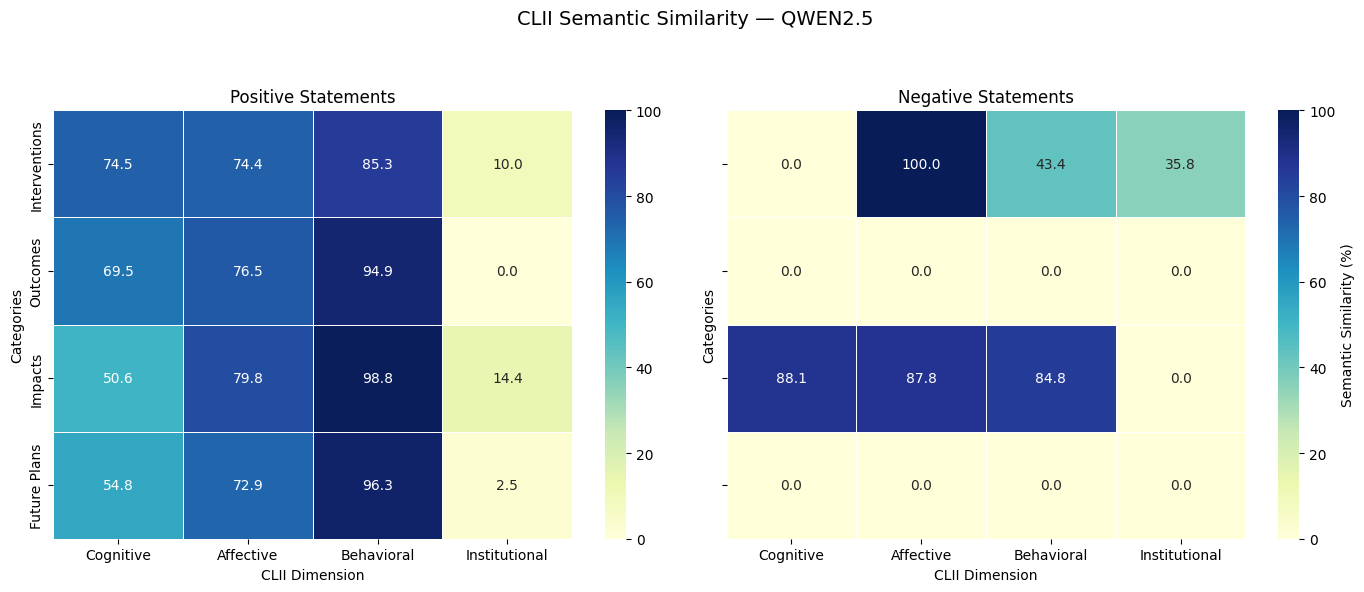

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

clii_columns = ["Cognitive", "Affective", "Behavioral", "Institutional"]

# Define all possible categories to ensure consistent y-axis
all_categories = ["interventions", "outcomes", "impacts", "future_goals"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, sentiment in enumerate(["positive", "negative"]):
    sub = qwen_df[qwen_df["sentiment"] == sentiment]
    mean_df = sub.groupby("field")[clii_columns].mean().reindex(all_categories)

    # Replace NaNs (for missing categories) with zeros or neutral values
    mean_df = mean_df.fillna(0)
    label_map = {
    "interventions": "Interventions",
    "outcomes": "Outcomes",
    "impacts": "Impacts",
    "future_goals": "Future Plans"
    }
    mean_df.index = mean_df.index.map(label_map)

    sns.heatmap(mean_df * 100, annot=True, fmt=".1f", cmap="YlGnBu",
                linewidths=0.4, ax=axes[i],
                cbar_kws={"label": "Semantic Similarity (%)"} if i == 1 else None,
                vmin=0, vmax=100)  # keeps same color scale

    axes[i].set_title(f"{sentiment.capitalize()} Statements")
    axes[i].set_xlabel("CLII Dimension")
    axes[i].set_ylabel("Categories")

plt.suptitle(f"CLII Semantic Similarity — {model_name.upper()}", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


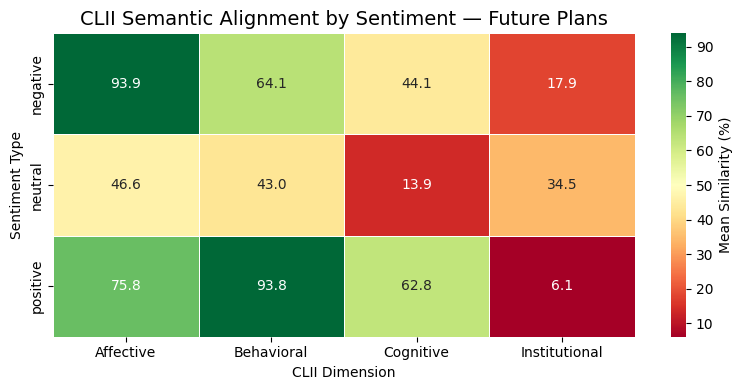

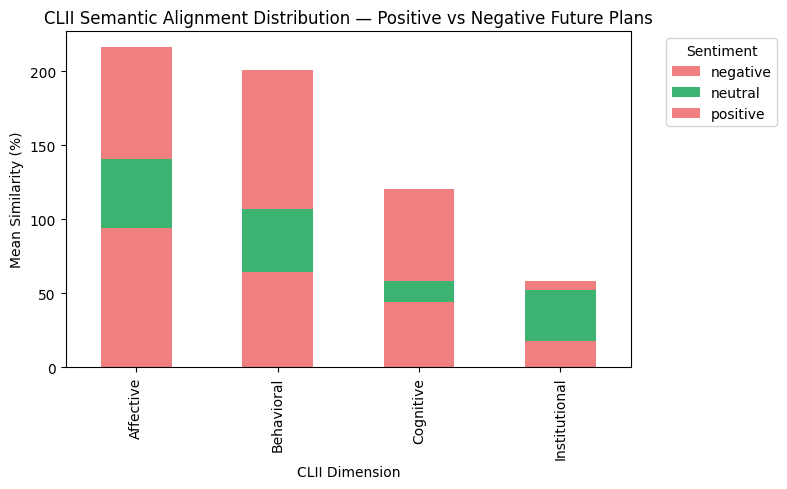

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# # Load your file
# with open("future_plans (1).json", "r", encoding="utf-8") as f:
#     data = json.load(f)

df = qwen_df#pd.DataFrame(data)

# --- Ensure correct columns ---
clii_cols = ["Cognitive", "Affective", "Behavioral", "Institutional"]

# --- Group by sentiment and average similarity ---
agg_df = df.groupby("sentiment")[clii_cols].mean().reset_index()

# --- Melt for easier plotting ---
melted = agg_df.melt(id_vars="sentiment", var_name="CLII Dimension", value_name="Mean Similarity")

# --- Convert similarity to percentage ---
melted["Mean Similarity (%)"] = melted["Mean Similarity"] * 100

# --- Plot heatmap ---
pivot_df = melted.pivot(index="sentiment", columns="CLII Dimension", values="Mean Similarity (%)")

plt.figure(figsize=(8, 4))
sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="RdYlGn", linewidths=0.5, cbar_kws={'label': 'Mean Similarity (%)'})
plt.title("CLII Semantic Alignment by Sentiment — Future Plans", fontsize=14)
plt.xlabel("CLII Dimension")
plt.ylabel("Sentiment Type")
plt.tight_layout()
plt.show()

# --- Optional: stacked bar chart version ---
pivot_df.T.plot(kind="bar", stacked=True, figsize=(8,5), color=["lightcoral", "mediumseagreen"])
plt.title("CLII Semantic Alignment Distribution — Positive vs Negative Future Plans")
plt.ylabel("Mean Similarity (%)")
plt.xlabel("CLII Dimension")
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
model_summary = (
    long_df.groupby("model")[["Cognitive", "Affective", "Behavioral", "Institutional"]]
    .sum()
)
model_summary["Total"] = model_summary.sum(axis=1)
model_summary = model_summary.sort_values("Total", ascending=False)
print(model_summary)


             Cognitive  Affective  Behavioral  Institutional       Total
model                                                                   
gpt-4o-mini  33.876491  46.366282   53.402712       7.421011  141.066496
qwen2.5      30.067345  42.097416   47.994486       8.107702  128.266949
llama3.1     29.992295  36.314468   43.248725       3.631536  113.187024


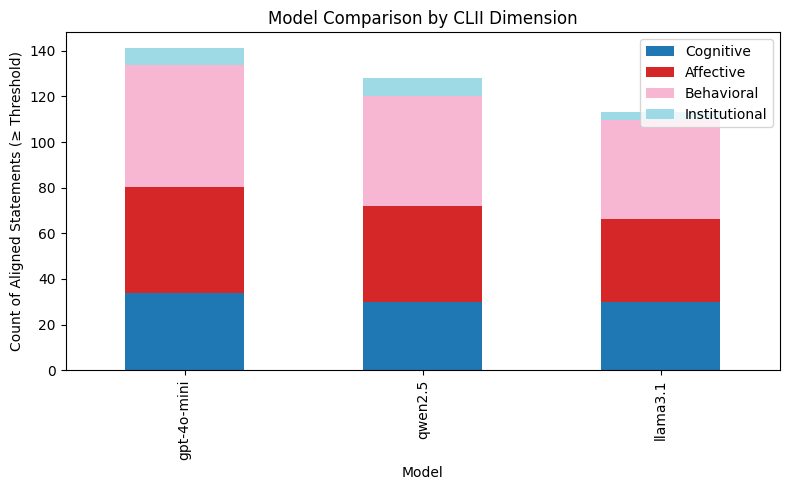

In [ ]:
model_summary[["Cognitive", "Affective", "Behavioral", "Institutional"]].plot(
    kind="bar", stacked=True, figsize=(8, 5), colormap="tab20"
)
plt.title("Model Comparison by CLII Dimension")
plt.ylabel("Count of Aligned Statements (≥ Threshold)")
plt.xlabel("Model")
plt.tight_layout()
plt.show()


In [ ]:
model_summary["Balance_Score"] = 1 - model_summary[
    ["Cognitive", "Affective", "Behavioral", "Institutional"]
].std(axis=1) / model_summary[
    ["Cognitive", "Affective", "Behavioral", "Institutional"]
].mean(axis=1)

print(model_summary.sort_values("Balance_Score", ascending=False))


             Cognitive  Affective  Behavioral  Institutional       Total  \
model                                                                      
qwen2.5      30.067345  42.097416   47.994486       8.107702  128.266949   
gpt-4o-mini  33.876491  46.366282   53.402712       7.421011  141.066496   
llama3.1     29.992295  36.314468   43.248725       3.631536  113.187024   

             Balance_Score  
model                       
qwen2.5           0.450242  
gpt-4o-mini       0.425979  
llama3.1          0.388206  


In [ ]:
st_model = SentenceTransformer("all-MiniLM-L6-v2")

100%|██████████| 39/39 [00:05<00:00,  6.56it/s]


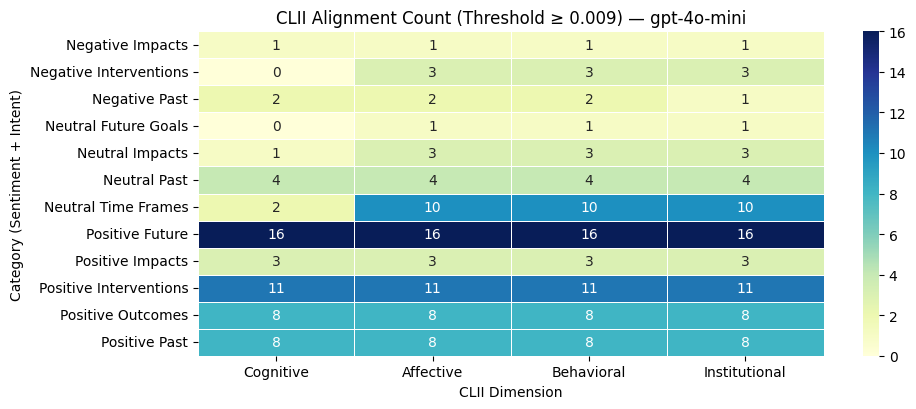

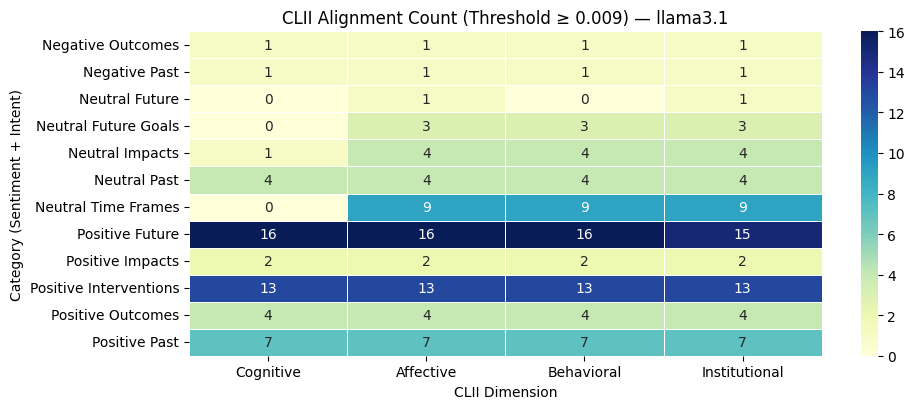

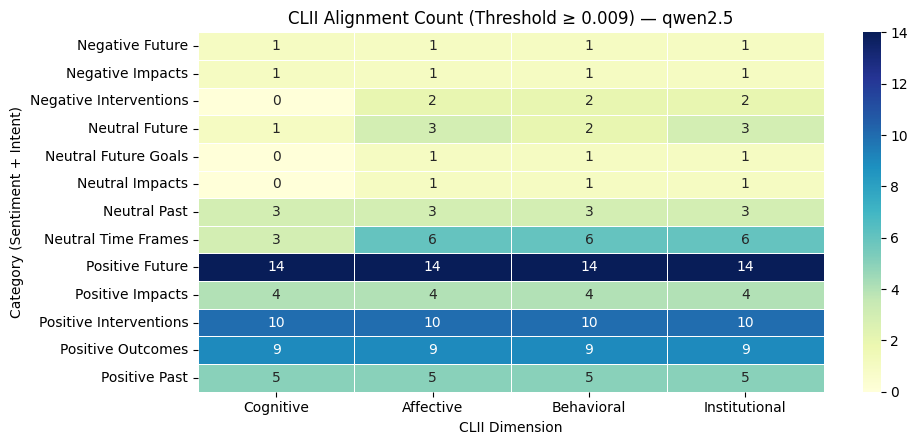

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# ---------------- Load and Setup ----------------
# df = new_data_df.copy()  # Replace with your DataFrame
df_test = pd.read_excel("sentiment_for_interventions_by_clii.xlsx")

fields = ["interventions", "outcomes", "impacts", "time_frames", "future_goals"]

# Verify columns
for f in fields:
    assert f in df_test.columns, f"Missing {f}"
    assert f"{f}_sentiment" in df_test.columns and f"{f}_timeframe" in df_test.columns, \
        f"Missing sentiment/timeframe columns for {f}"

if "model" not in df_test.columns:
    df_test["model"] = "all_models"

# ---------------- CLII Anchors ----------------
clii_anchors = {
    "Cognitive": "knowledge, awareness, understanding of climate change and climate literacy",
    "Affective": "emotional engagement, concern, motivation, attitudes toward climate action",
    "Behavioral": "actions, practices, participation, adoption of climate mitigation/adaptation behaviors",
    "Institutional": "policy, curriculum, governance, institutional integration and capacity building"
}


anchor_names = list(clii_anchors.keys())
anchor_embs = st_model.encode(list(clii_anchors.values()), convert_to_tensor=True)

# ---------------- Similarity Function ----------------
def clii_similarity_vector(text):
    """Return similarity dict for each CLII dimension."""
    if not isinstance(text, str) or text.strip().lower() in ["none", "", "nan"]:
        return {k: 0.0 for k in anchor_names}
    emb = st_model.encode(text, convert_to_tensor=True)
    sims = util.cos_sim(emb, anchor_embs).cpu().numpy().flatten()
    sims = np.clip(sims, 0, 1)
    return dict(zip(anchor_names, sims))

# ---------------- Create Long Table ----------------
rows = []
for idx, row in tqdm(df_test.iterrows(), total=len(df_test)):
    for f in fields:
        text = row.get(f, "")
        sim = clii_similarity_vector(str(text))
        sentiment = str(row.get(f"{f}_sentiment", "neutral")).lower()
        timeframe = str(row.get(f"{f}_timeframe", "present")).lower()

        # Build human-readable category
        category = f"{sentiment.capitalize()} {f.replace('_',' ').title()}"
        if timeframe == "future":
            category = f"{sentiment.capitalize()} Future"
        elif timeframe == "past":
            category = f"{sentiment.capitalize()} Past"

        rows.append({
            "document_id": row.get("document_id", idx),
            "model": row.get("model", "all_models"),
            "field": f,
            "category": category,
            "sentiment": sentiment,
            "timeframe": timeframe,
            **sim
        })

long_df = pd.DataFrame(rows)

# ---------------- Thresholded Counts ----------------
THRESHOLD = 0.009

# Convert similarities to binary flags (1 if ≥ threshold)
binary_df = long_df.copy()
for col in anchor_names:
    binary_df[col] = (binary_df[col] >= THRESHOLD).astype(int)

# Count how many field items pass threshold per model × category × CLII
agg_counts = (
    binary_df.groupby(["model", "category"])[anchor_names]
    .sum()
    .reset_index()
)

# ---------------- Plot Heatmaps ----------------
models = agg_counts["model"].unique()
for model_name in models:
    sub = agg_counts[agg_counts["model"] == model_name].set_index("category")
    if sub.shape[0] == 0:
        continue

    plt.figure(figsize=(10, max(4, 0.35 * sub.shape[0])))
    sns.heatmap(sub[anchor_names], annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
    plt.title(f"CLII Alignment Count (Threshold ≥ {THRESHOLD}) — {model_name}")
    plt.xlabel("CLII Dimension")
    plt.ylabel("Category (Sentiment + Intent)")
    plt.tight_layout()
    plt.show()


In [ ]:
long_df.to_

In [ ]:
llama_data_df = pd.read_excel('llama_user_2_matches.xlsx')
gpt_data_df = pd.read_excel('gpt_user_2_matches.xlsx')
qwen_data_df = pd.read_excel('qwen_user_2_matches.xlsx')

llama_data_df = llama_data_df[['summary_llama',
       'community_llama', 'project_name_llama', 'time_frame_llama',
       'future_goals_llama', 'intervention_llama', 'outcome_llama', 'impact_llama',
       'sdg_13_3_llama', 'sa_project_llama', 'climate_related_llama', 'text_llama',
       'index_llama']]
gpt_data_df = gpt_data_df[['summary_gpt',
       'community_gpt', 'project_name_gpt', 'time_frame_gpt',
       'future_goals_gpt', 'intervention_gpt', 'outcome_gpt', 'impact_gpt',
       'sdg_13_3_gpt', 'sa_project_gpt', 'climate_related_gpt', 'text_gpt',
       'index_gpt']]
qwen_data_df = qwen_data_df[['summary_qwen',
       'community_qwen', 'project_name_qwen', 'time_frame_qwen',
       'future_goals_qwen', 'intervention_qwen', 'outcome_qwen', 'impact_qwen',
       'sdg_13_3_qwen', 'sa_project_qwen', 'climate_related_qwen', 'text_qwen',
       'index_qwen']]

# Rename columns
# llama_data_df = pd.read_json('llama_user_2_matches.json')
llama_data_df.rename(columns={'climate_related_llama': 'climate_related', 'summary_llama': 'summary', 'community_llama': 'communities',
       'project_name_llama': 'project_name', 'time_frame_llama': 'time_frames',
       'future_goals_llama': 'future_goals', 'intervention_llama': 'intervention_type', 'outcome_llama': 'outcomes', 'impact_llama': 'impacts',
       'sdg_13_3_llama': 'interventions', 'sa_project_llama': 'sa_project', 'text_llama': 'text',
       'index_llama': 'index'}, inplace=True)

gpt_data_df.rename(columns={'climate_related_gpt': 'climate_related', 'summary_gpt': 'summary', 'community_gpt': 'communities',
       'project_name_gpt': 'project_name', 'time_frame_gpt': 'time_frames',
       'future_goals_gpt': 'future_goals', 'intervention_gpt': 'intervention_type', 'outcome_gpt': 'outcomes', 'impact_gpt': 'impacts',
       'sdg_13_3_gpt': 'interventions', 'sa_project_gpt': 'sa_project', 'text_gpt': 'text',
       'index_gpt': 'index'}, inplace=True)

qwen_data_df.rename(columns={'climate_related_qwen': 'climate_related', 'summary_qwen': 'summary', 'community_qwen': 'communities',
       'project_name_qwen': 'project_name', 'time_frame_qwen': 'time_frames',
       'future_goals_qwen': 'future_goals', 'intervention_qwen': 'intervention_type', 'outcome_qwen': 'outcomes', 'impact_qwen': 'impacts',
       'sdg_13_3_qwen': 'interventions', 'sa_project_qwen': 'sa_project', 'text_qwen': 'text',
       'index_qwen': 'index'}, inplace=True)

llama_data_df["document_id"] = llama_data_df.index + 1
llama_data_df['model'] = 'llama3.1'
gpt_data_df["document_id"] = gpt_data_df.index + 1
gpt_data_df['model'] = 'gpt-4o-mini'
qwen_data_df["document_id"] = qwen_data_df.index + 1
qwen_data_df['model'] = 'qwen2.5'

print(len(llama_data_df),  llama_data_df.columns)
print(len(gpt_data_df),  gpt_data_df.columns)
print(len(qwen_data_df),  qwen_data_df.columns)

26 Index(['summary', 'communities', 'project_name', 'time_frames', 'future_goals',
       'intervention_type', 'outcomes', 'impacts', 'interventions',
       'sa_project', 'climate_related', 'text', 'index', 'document_id',
       'model'],
      dtype='object')
26 Index(['summary', 'communities', 'project_name', 'time_frames', 'future_goals',
       'intervention_type', 'outcomes', 'impacts', 'interventions',
       'sa_project', 'climate_related', 'text', 'index', 'document_id',
       'model'],
      dtype='object')
26 Index(['summary', 'communities', 'project_name', 'time_frames', 'future_goals',
       'intervention_type', 'outcomes', 'impacts', 'interventions',
       'sa_project', 'climate_related', 'text', 'index', 'document_id',
       'model'],
      dtype='object')


In [ ]:
# Install required packages first (if not installed):
# pip install pandas spacy sentence-transformers scikit-learn openai plotly
# python -m spacy download en_core_web_sm

import pandas as pd
import spacy
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer, util
from openai import OpenAI
import numpy as np
import plotly.express as px
import re
from collections import Counter
from langchain_openai import ChatOpenAI


# 🔑 Initialize
nlp = spacy.load("en_core_web_sm")
# embedder = SentenceTransformer('all-MiniLM-L6-v2')
# client = OpenAI()  # assumes your OPENAI_API_KEY is set in environment
client = ChatOpenAI(model="gpt-5-2025-08-07", temperature=0, openai_api_key=OPENAI_KEY)
# ------------------------------------
# 1️⃣ Load the three model outputs
# ------------------------------------
models = {
    "gpt4o-mini": gpt_data_df,
    "llama3.1": llama_data_df,
    "qwen2.5": qwen_data_df,
}

fields = ["communities", "interventions", "outcomes", "impacts", "time_frames"]

# ------------------------------------
# 2️⃣ Traditional NLP Cleaning
# ------------------------------------
def normalize_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def extract_noun_phrases(text):
    doc = nlp(text)
    return [chunk.text for chunk in doc.noun_chunks if len(chunk.text.split()) >= 2]

# Apply to all models
for model_name, df in models.items():
    for fld in fields:
        col = fld + "_clean"
        df[col] = df[fld].astype(str).apply(normalize_text)
        df[fld + "_phrases"] = df[col].apply(extract_noun_phrases)

# ------------------------------------
# 3️⃣ Build a Combined Phrase Corpus
# ------------------------------------
phrase_records = []
for model_name, df in models.items():
    for fld in fields:
      for _, row in df.iterrows():
        for phrase in row[fld + "_phrases"]:
            phrase_records.append({
                "document_id": row["document_id"],
                "model": model_name,
                "field": fld,
                "phrase": phrase
                })
            # for p in phrases:

phrase_df = pd.DataFrame(phrase_records)
print(f"Total phrases collected: {len(phrase_df)}")

# ------------------------------------
# 4️⃣ Embeddings + Clustering
# ------------------------------------
all_phrases = phrase_df["phrase"].tolist()
embeddings = sentence_transformer.encode(all_phrases, convert_to_tensor=True)
num_clusters = min(10, len(all_phrases)) # adjust depending on variety of data
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings.cpu().numpy())
phrase_df["cluster"] = labels

# ------------------------------------
# 5️⃣ GenAI-as-a-Judge: Cluster Summarization
# ------------------------------------
def summarize_cluster(phrases):
    text_sample = "; ".join(phrases[:10])  # send up to 10 phrases for context
    prompt = f"""
    The following phrases describe extractions from climate-related studies:
    {text_sample}
    Please summarize them into one short representative label that best captures their shared meaning.
    Respond only with the label, nothing else.
    """
    print(f"Phrases: {text_sample}")
    try:
        messages=[{"role": "user", "content": prompt}]
        response = client.invoke(messages)
        return response.content.strip()
    except Exception as e:
        print("Judge error:", e)
        return "unspecified cluster"

cluster_labels = phrase_df.groupby("cluster")["phrase"].apply(list).apply(summarize_cluster)
label_map = cluster_labels.to_dict()
phrase_df["cluster_label"] = phrase_df["cluster"].map(label_map)


# --------------------------------
# 6️⃣ Compute Presence Matrix (Cluster × Field)
# --------------------------------
presence = (
    phrase_df.groupby(["cluster_label", "field"])["document_id"]
    .nunique()
    .reset_index(name="doc_count")
)
presence_matrix = presence.pivot_table(
    index="cluster_label", columns="field", values="doc_count", fill_value=0
)
presence_norm = presence_matrix.div(presence_matrix.sum(axis=1), axis=0)


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import plotly.graph_objects as go
# --------------------------------
# 7️⃣ Visualize Heatmaps
# --------------------------------
plt.figure(figsize=(12, max(4, 0.5*len(presence_matrix))))
sns.heatmap(
    presence_matrix.astype(int),
    cmap="YlOrRd",
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Number of Papers Mentioning Concept"}
)
plt.title("Distribution of Interventions, Outcomes, and Impacts across Clusters")
plt.xlabel("Classes")
plt.ylabel("Cluster (Climate Concept)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, max(4, 0.5*len(presence_norm))))
sns.heatmap(
    presence_norm,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Proportion of Mentions per Cluster"}
)
plt.title("Relative Representation of Evidence across Classes")
plt.xlabel("Classes")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

# --------------------------------
# 8️⃣ Sankey Diagram (Flow Visualization)
# --------------------------------
link_records = []
for doc_id, group in phrase_df.groupby("document_id"):
    interventions = group[group["field"] == "interventions"]["cluster_label"].unique()
    outcomes = group[group["field"] == "outcomes"]["cluster_label"].unique()
    impacts = group[group["field"] == "impacts"]["cluster_label"].unique()

    for i in interventions:
        for o in outcomes:
            link_records.append(("Intervention: " + i, "Outcome: " + o))
        for imp in impacts:
            link_records.append(("Intervention: " + i, "Impact: " + imp))
    for o in outcomes:
        for imp in impacts:
            link_records.append(("Outcome: " + o, "Impact: " + imp))

from collections import Counter
link_counts = Counter(link_records)

if link_counts:
    labels = list({n for pair in link_counts.keys() for n in pair})
    label_map = {label: idx for idx, label in enumerate(labels)}
    sources = [label_map[pair[0]] for pair in link_counts.keys()]
    targets = [label_map[pair[1]] for pair in link_counts.keys()]
    values = [v for v in link_counts.values()]

    fig = go.Figure(data=[go.Sankey(
        node=dict(label=labels, pad=15, thickness=20),
        link=dict(source=sources, target=targets, value=values)
    )])
    fig.update_layout(title_text="Flow of Concepts: Intervention → Outcome → Impact", font_size=10)
    fig.show()

# --------------------------------
# 9️⃣ Save Results
# --------------------------------
phrase_df.to_csv("hybrid_semantic_clusters.csv", index=False)
presence_matrix.to_csv("impact_presence_matrix.csv")
presence_norm.to_csv("impact_presence_normalized.csv")
print("✅ Saved:")
print(" - hybrid_semantic_clusters.csv")
print(" - impact_presence_matrix.csv")
print(" - impact_presence_normalized.csv")

